# nb_steps=1 vs nb_steps=2 comparison (quick): common_input=false, task-routed, low sparsity

This notebook runs a **quick, reduced participant** comparison for the two-module RNN with **common_input=false** (modular input separation), **task-routed input**, **shared output**, and **sparse communication** (low sparsity), once with **nb_steps=1** and once with **nb_steps=2**. It uses a small participant subset for a fast sanity check, then runs transfer/loss/PCA/principal-angle analysis and figures.

Run cells in order. Results are saved under `nb_steps_comparison/task_routed_low_sparse_sep_nb1` and `_nb2` so they do not overwrite the full comparison runs.

## 1. Setup and paths

In [1]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root (parent of a1b2)
project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.data.basic_funcs import set_seed
from a1b2.training.simulation import run_simulation
from a1b2.analysis import transfer_interference as ann
from a1b2.utils.figure_settings import schedule_colours, condition_order

data_folder = project_root / "data"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)
print("Project root:", project_root)

/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular


## 2. Participant subset (reduced for quick run)

Build a small balanced subset (N_PER_SCHEDULE per same/near/far) so both nb1 and nb2 runs use the same participants and all three schedules are represented.

In [2]:
N_PER_SCHEDULE = 3  # reduced for quick run (same, near, far) -> 9 total
SUBSET_SEED = 42

df = ann.load_participant_data(str(data_folder))
all_participants = df["participant"].unique()

# Group by schedule (participant ID contains 'same', 'near', or 'far')
by_schedule = {"same": [], "near": [], "far": []}
for pid in all_participants:
    pid_str = str(pid)
    if "same" in pid_str:
        by_schedule["same"].append(pid)
    elif "near" in pid_str:
        by_schedule["near"].append(pid)
    elif "far" in pid_str:
        by_schedule["far"].append(pid)

np.random.seed(SUBSET_SEED)
subset = []
for sched in condition_order:
    pool = by_schedule[sched]
    n_take = min(N_PER_SCHEDULE, len(pool))
    if n_take > 0:
        idx = np.random.choice(len(pool), size=n_take, replace=False)
        subset.extend([pool[i] for i in idx])

participants_subset = list(subset)
print(f"Subset: {len(participants_subset)} participants ({N_PER_SCHEDULE} per schedule)")
print(f"  same: {sum(1 for p in participants_subset if 'same' in str(p))}")
print(f"  near: {sum(1 for p in participants_subset if 'near' in str(p))}")
print(f"  far:  {sum(1 for p in participants_subset if 'far' in str(p))}")

Subset: 9 participants (3 per schedule)
  same: 3
  near: 3
  far:  3


## 3. Run simulations (nb1 and nb2) to comparison folders

Conditions use **common_input=false**. Save to `task_routed_low_sparse_sep_nb1` and `_nb2` under nb_steps_comparison so we do not overwrite the full or legacy comparison runs.

In [3]:
CONDITION_NB1 = "two_module_rnn_50_task_routed_low_sparse"
CONDITION_NB2 = "two_module_rnn_50_task_routed_low_sparse_nb2"
comparison_base = data_folder / "simulations" / "nb_steps_comparison"
comparison_base.mkdir(parents=True, exist_ok=True)

task_parameters = ann.setup_task_parameters()
dim_input = task_parameters["nStim_perTask"] * 2
dim_output = 4

def run_one_condition(condition_name, sim_subfolder):
    condition = next((c for c in settings["conditions"] if c["name"] == condition_name), None)
    if condition is None:
        raise ValueError(f"Condition '{condition_name}' not found")
    arch = condition.get("arch", "ffn")
    n_modules = condition.get("n_modules", 2 if arch == "two_module_rnn" else 1)
    dim_hidden = n_modules * condition.get("dim_hidden", 50)
    network_params = [dim_input, dim_hidden, dim_output]
    training_params = [
        participants_subset,
        settings["n_phase"],
        settings["n_epochs"],
        settings["n_epochs"] * (task_parameters["nStim_perTask"] * 2) * 10,
        settings["shuffle"],
        settings["batch_size"],
        condition.get("gamma", 0.01),
        settings["learning_rate"],
    ]
    sim_folder = comparison_base / sim_subfolder
    sim_folder.mkdir(parents=True, exist_ok=True)
    settings_to_save = {
        "condition": condition,
        "training_params": {
            "participants": [str(p) for p in participants_subset],
            "n_phase": settings["n_phase"], "n_epochs": settings["n_epochs"],
            "shuffle": settings["shuffle"], "batch_size": settings["batch_size"],
            "gamma": condition.get("gamma", 0.01), "lr": settings["learning_rate"],
        },
        "network_params": network_params,
        "task_parameters": task_parameters,
    }
    settings_to_save = ann.numpy_to_python(settings_to_save)
    with open(sim_folder / "settings.json", "w") as f:
        json.dump(settings_to_save, f, indent=2)
    run_simulation(
        training_params, network_params, task_parameters, df,
        do_test=1, dosave=1, sim_folder=str(sim_folder),
        arch=arch, condition=condition if arch in ("two_module_rnn", "single_module_rnn") else None,
    )
    print(f"Done: {condition_name} -> {sim_folder}")

### Training

In [4]:
#set_seed(2024)
#run_one_condition(CONDITION_NB1, "task_routed_low_sparse_sep_nb1")

In [5]:
#set_seed(2024)
#run_one_condition(CONDITION_NB2, "task_routed_low_sparse_sep_nb2")

## 4. Load data and compute metrics

Load both run folders with `load_rnn_extra=True` so nb2 trajectory/per-module keys are available. Compute transfer, loss, PCA, principal angles; add `run_label` for plotting.

In [6]:
folders = {
    "nb1": comparison_base / "task_routed_low_sparse_sep_nb1",
    "nb2": comparison_base / "task_routed_low_sparse_sep_nb2",
}
all_ann_data = {}
for label, path in folders.items():
    if path.exists():
        all_ann_data[label] = ann.load_ann_data(str(path), load_rnn_extra=True)
    else:
        print(f"Warning: {path} not found. Run the simulation cell first.")

transfer_dfs = []
loss_results = {}
loss_results_holton = {}  # trained-per-phase (summer in A2) for Holton-like curves
pca_dfs = []
angle_dfs = []
for run_label, data in all_ann_data.items():
    tr = ann.compute_transfer_anns(data)
    tr["run_label"] = run_label
    transfer_dfs.append(tr)
    loss_results[run_label] = ann.analyze_training_loss(data)
    loss_results_holton[run_label] = ann.analyze_training_loss(data, feature_style='trained_per_phase')
    pc = ann.compute_pca_components(data, variance_threshold=0.99)
    pc["run_label"] = run_label
    pca_dfs.append(pc)
    ang = ann.get_principal_angles(data)
    ang["run_label"] = run_label
    angle_dfs.append(ang)

transfer_all = pd.concat(transfer_dfs, ignore_index=True) if transfer_dfs else pd.DataFrame()
pca_all = pd.concat(pca_dfs, ignore_index=True) if pca_dfs else pd.DataFrame()
angles_all = pd.concat(angle_dfs, ignore_index=True) if angle_dfs else pd.DataFrame()

# table for mean and sem of error_diff, which means transfer error for nb1 vs nb2 mean value and standard error of the mean
print("Loaded runs:", list(all_ann_data.keys()))
if not transfer_all.empty:
    print(transfer_all.groupby(["run_label", "condition"])["error_diff"].agg(["mean", "sem"]))

Loaded runs: ['nb1', 'nb2']
                         mean       sem
run_label condition                    
nb1       far       -0.437037  0.026286
          near      -0.394815  0.056285
          same      -0.319635  0.023738
nb2       far       -0.417879  0.012412
          near      -0.372629  0.017298
          same      -0.351015  0.017634


## 5. Figures and metrics

**Transfer:** mean (SEM) error_diff per schedule, nb1 vs nb2. **Loss:** mean loss over epochs. **PCA:** n_components for 99% variance. **Principal angles:** by schedule. **Trajectory:** sanity check for nb2.

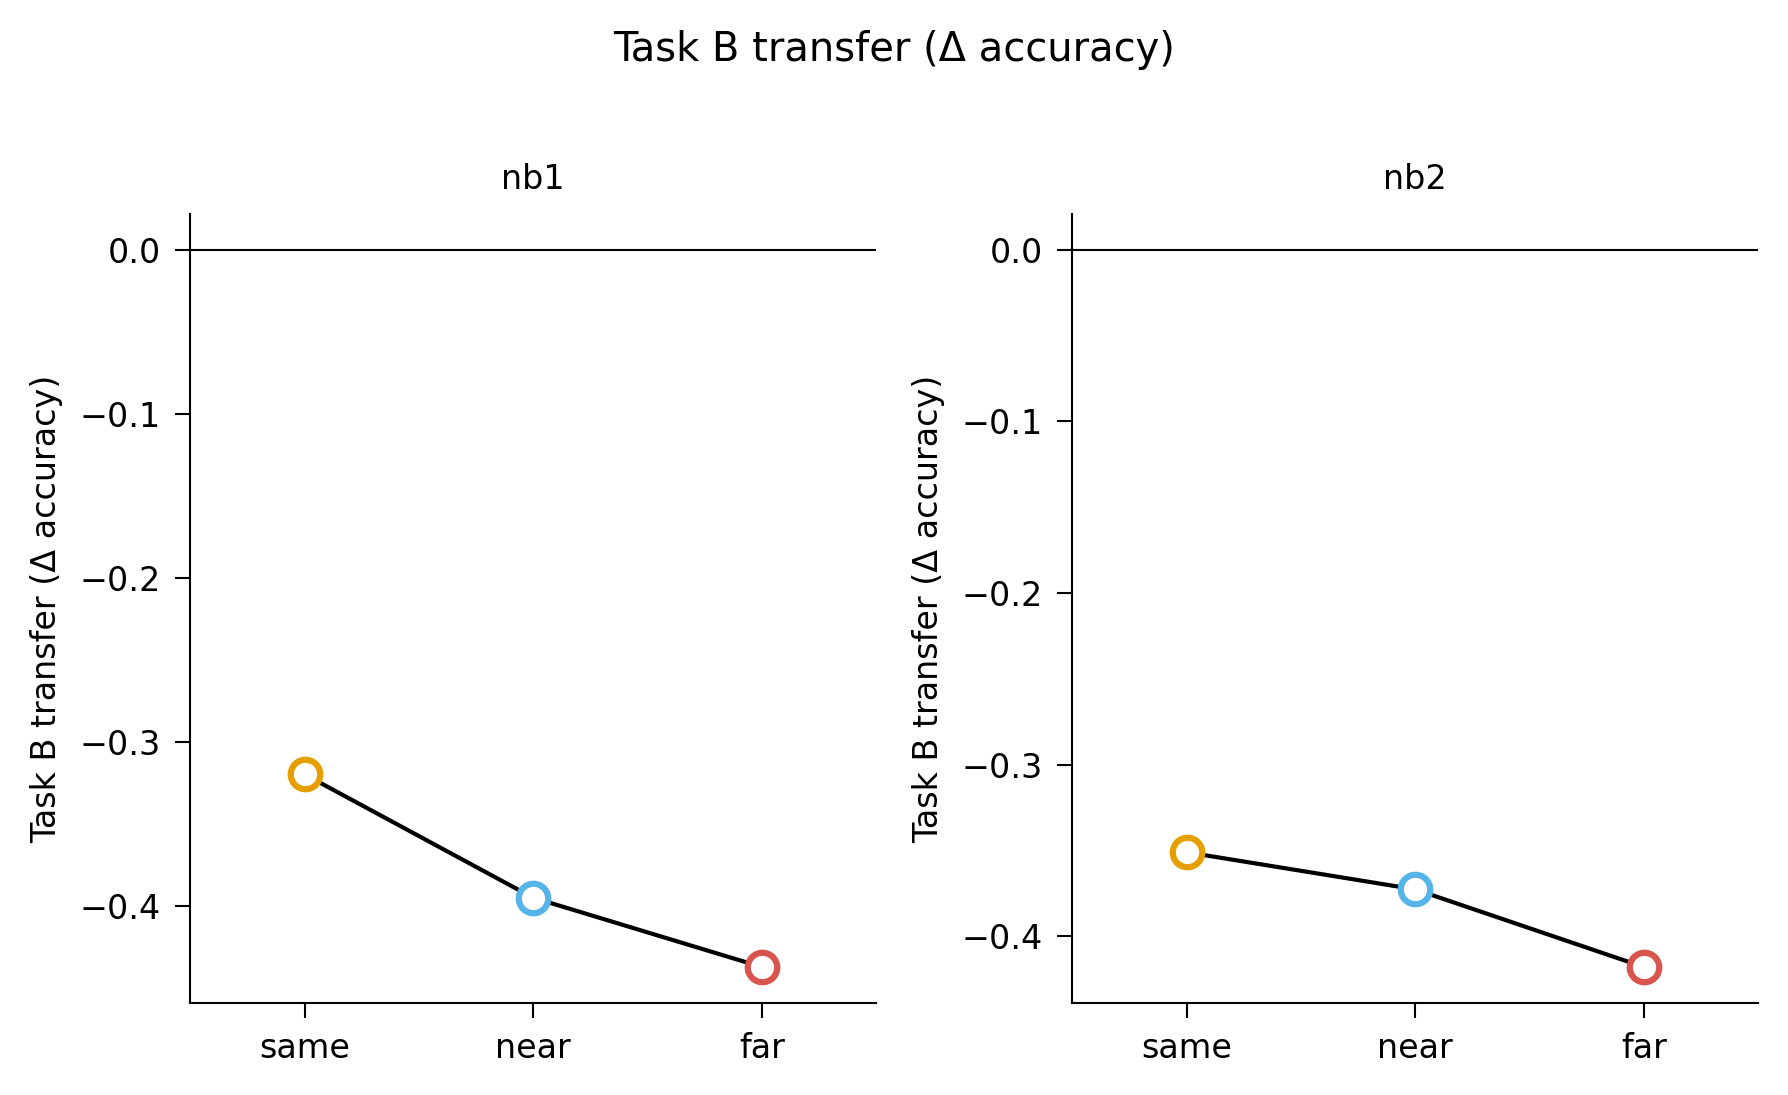

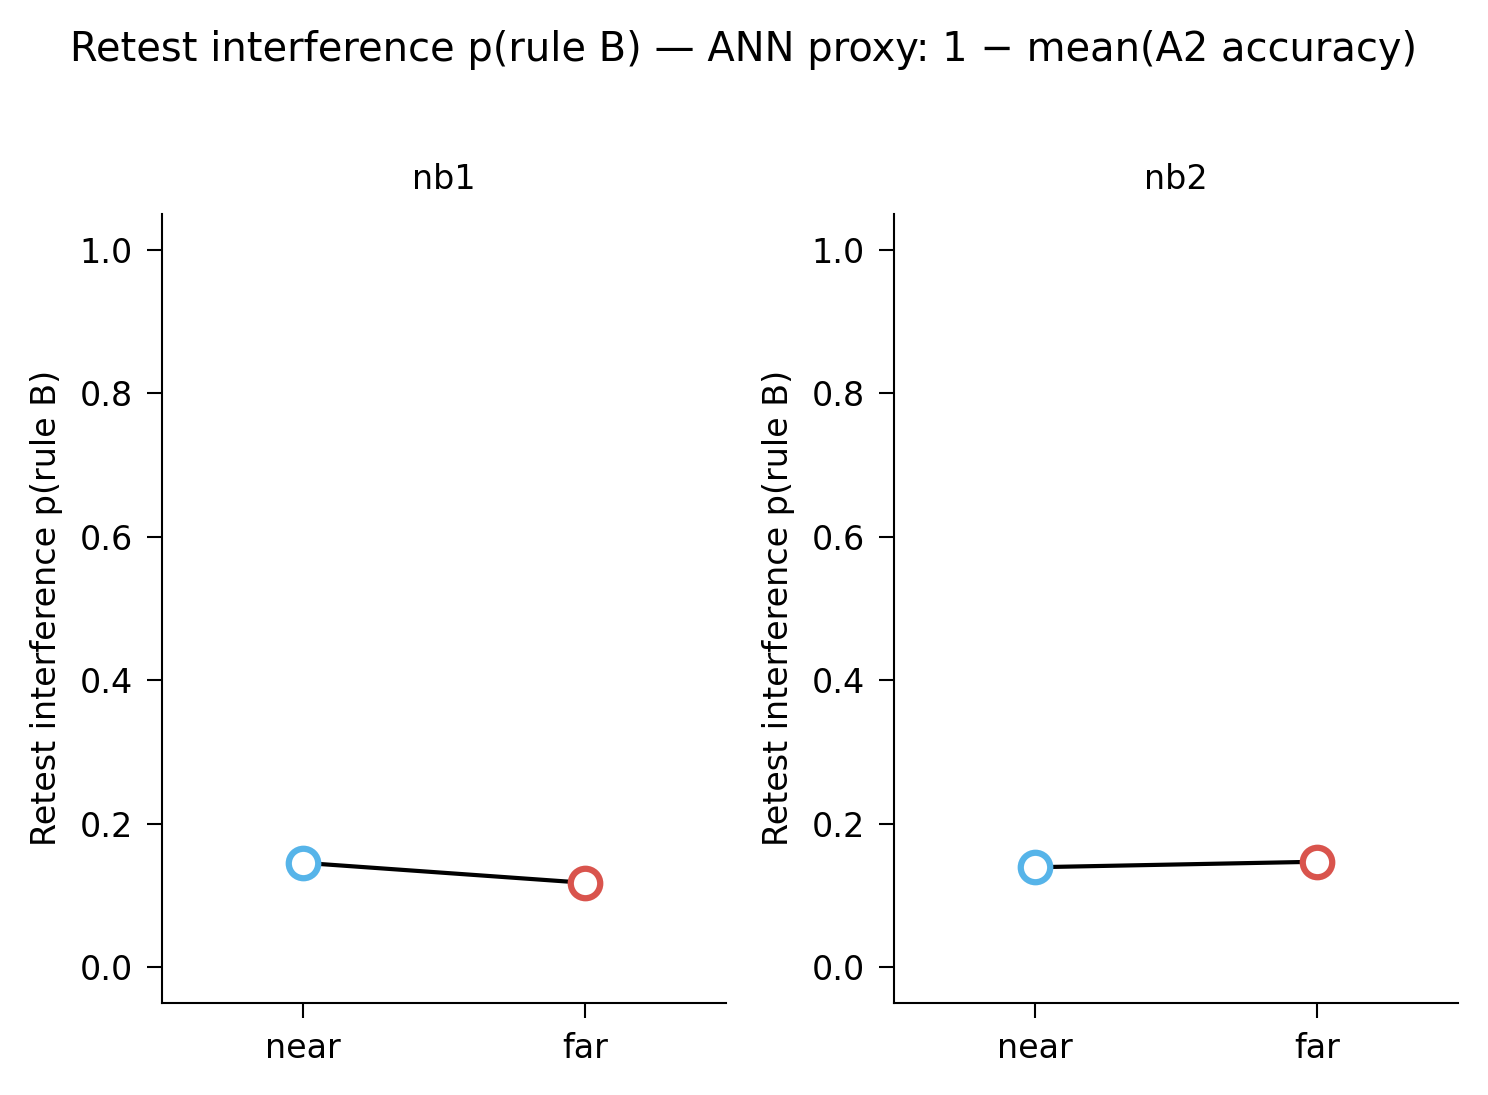

In [7]:
# Holton-style: Task B transfer (Δ accuracy) and Retest interference p(rule B), one subplot per config (nb1, nb2)
from a1b2.utils.figure_utils import _style_axes

run_labels = ["nb1", "nb2"]
if transfer_all.empty:
    print("No transfer data to plot. Run simulations and load cell first.")
else:
    agg = transfer_all.groupby(["run_label", "condition"], as_index=False)["error_diff"].agg(["mean", "sem"]).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
    if axes.ndim == 0:
        axes = [axes]
    x_t = np.arange(len(condition_order))
    for idx, run_label in enumerate(run_labels):
        ax = axes[idx]
        if run_label not in agg["run_label"].values:
            ax.set_visible(False)
            continue
        means = [agg[(agg["run_label"] == run_label) & (agg["condition"] == s)]["mean"].values for s in condition_order]
        means = [float(m[0]) if len(m) else np.nan for m in means]
        ax.plot(x_t, means, color="black", linewidth=1)
        for c, (s, m) in enumerate(zip(condition_order, means)):
            if np.isnan(m):
                continue
            ax.scatter(c, m, facecolors="white", edgecolors=schedule_colours[c], linewidths=1.5, s=50, zorder=3)
        ax.set_xticks(x_t)
        ax.set_xticklabels(condition_order)
        ax.set_ylabel("Task B transfer (Δ accuracy)")
        ax.set_xlim(-0.5, len(condition_order) - 0.5)
        ax.axhline(0, color="k", linewidth=0.5)
        ax.set_title(run_label)
        _style_axes(ax)
    fig.suptitle("Task B transfer (Δ accuracy)", y=1.02)
    fig.tight_layout()
    plt.show()

# Retest interference p(rule B): ANN proxy = 1 - mean(A2 accuracy) per run/condition (Near, Far only)
interference_order = ["near", "far"]
interference_rows = []
if all_ann_data:
    for run_label in run_labels:
        if run_label not in all_ann_data:
            continue
        for sched in interference_order:
            if sched not in all_ann_data[run_label] or len(all_ann_data[run_label][sched]) == 0:
                continue
            for subj in range(len(all_ann_data[run_label][sched])):
                acc = all_ann_data[run_label][sched][subj].get("accuracy")
                if acc is None or acc.ndim < 2:
                    continue
                a2_acc = np.mean(acc[2, 1::2])
                interference_rows.append({"run_label": run_label, "condition": sched, "interference": 1 - a2_acc})
interference_df = pd.DataFrame(interference_rows) if interference_rows else pd.DataFrame()

if interference_df.empty:
    print("No data for retest interference plot (need all_ann_data).")
else:
    agg_int = interference_df.groupby(["run_label", "condition"], as_index=False)["interference"].agg(["mean", "sem"]).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(5, 3.5))
    if axes.ndim == 0:
        axes = [axes]
    x_i = np.arange(len(interference_order))
    for idx, run_label in enumerate(run_labels):
        ax = axes[idx]
        if run_label not in agg_int["run_label"].values:
            ax.set_visible(False)
            continue
        means = [agg_int[(agg_int["run_label"] == run_label) & (agg_int["condition"] == s)]["mean"].values for s in interference_order]
        means = [float(m[0]) if len(m) else np.nan for m in means]
        ax.plot(x_i, means, color="black", linewidth=1)
        for c, (s, m) in enumerate(zip(interference_order, means)):
            if np.isnan(m):
                continue
            ax.scatter(c, m, facecolors="white", edgecolors=schedule_colours[condition_order.index(s)], linewidths=1.5, s=50, zorder=3)
        ax.set_xticks(x_i)
        ax.set_xticklabels(interference_order)
        ax.set_ylabel("Retest interference p(rule B)")
        ax.set_xlim(-0.5, len(interference_order) - 0.5)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(run_label)
        _style_axes(ax)
    fig.suptitle("Retest interference p(rule B) — ANN proxy: 1 − mean(A2 accuracy)", y=1.02)
    fig.tight_layout()
    plt.show()

### Accuracy timecourse (summer & winter, A1 + B)

ANN accuracy curves by config: one subplot per (run_label × condition). In each panel, block on x-axis (A1 then B), accuracy on y; two lines — summer (probe 0) and winter (probe 1). Vertical line at block 10 = A1/B boundary. Same style as `figure_utils.plot_accuracy_timecourse`.

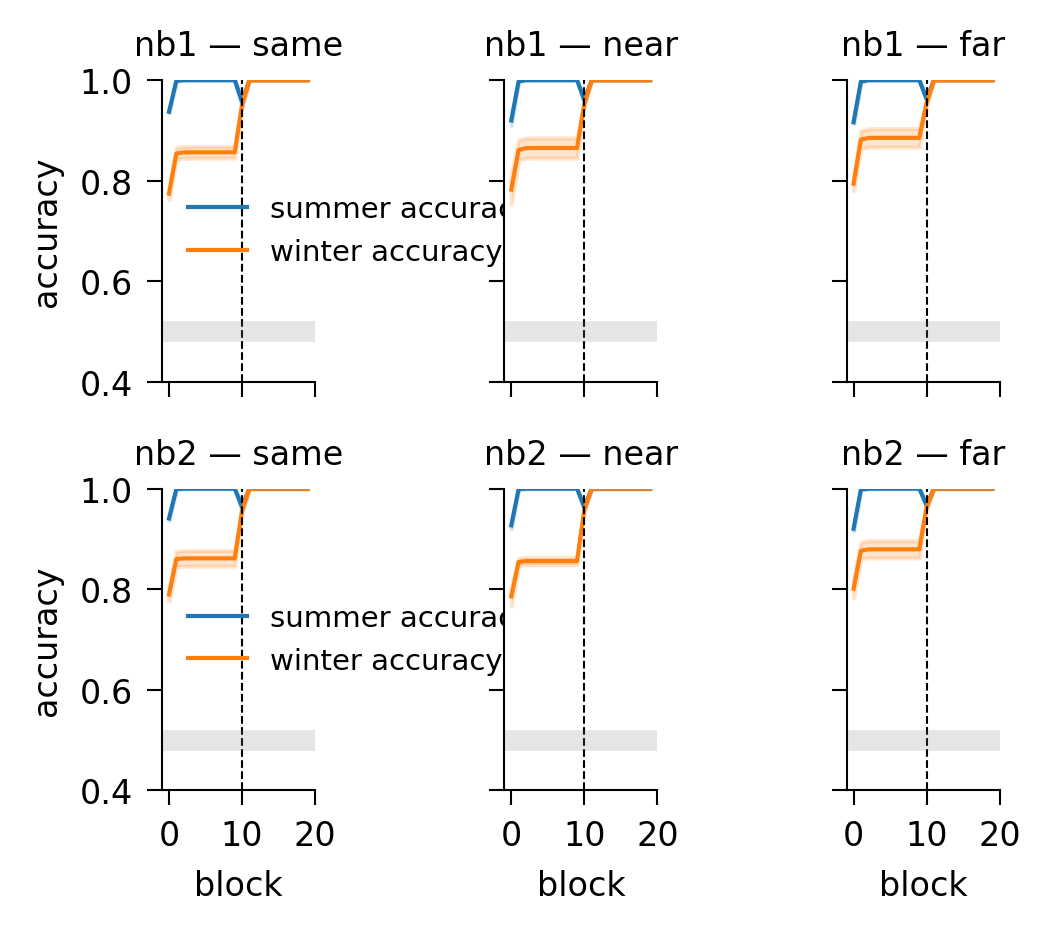

In [ ]:
# Build ANN trial-level dataframe for accuracy timecourse: block (0..19), feature_idx (0 summer, 1 winter), accuracy; A1 = blocks 0..9, B = 10..19
import seaborn as sns
from a1b2.utils.figure_utils import _style_axes

acc_timecourse_rows = []
n_blocks_per_phase = 10
run_labels = ["nb1", "nb2"]
schedules = condition_order  # same, near, far

if all_ann_data:
    for run_label in run_labels:
        if run_label not in all_ann_data:
            continue
        for sched in schedules:
            if sched not in all_ann_data[run_label] or len(all_ann_data[run_label][sched]) == 0:
                continue
            for subj_idx, subj_data in enumerate(all_ann_data[run_label][sched]):
                acc = subj_data.get("accuracy")
                if acc is None or acc.ndim < 2:
                    continue
                n_phase, n_trials = acc.shape[0], acc.shape[1]
                # A1 = phase 0, B = phase 1 (skip A2)
                for phase, task_section in enumerate(("A1", "B")):
                    if phase >= n_phase:
                        break
                    n_here = n_trials
                    block_size = max(1, n_here // n_blocks_per_phase)
                    for b in range(n_blocks_per_phase):
                        start = b * block_size
                        end = min((b + 1) * block_size, n_here)
                        if start >= end:
                            continue
                        global_block = b + phase * n_blocks_per_phase  # 0..9 A1, 10..19 B
                        summer_acc = np.nanmean(acc[phase, start:end:2])
                        winter_acc = np.nanmean(acc[phase, start+1:end:2]) if end - start > 1 else np.nan
                        acc_timecourse_rows.append({
                            "run_label": run_label, "condition": sched, "participant": subj_idx,
                            "block": global_block, "task_section": task_section,
                            "feature_idx": 0, "feature": "summer accuracy", "accuracy": summer_acc
                        })
                        acc_timecourse_rows.append({
                            "run_label": run_label, "condition": sched, "participant": subj_idx,
                            "block": global_block, "task_section": task_section,
                            "feature_idx": 1, "feature": "winter accuracy", "accuracy": winter_acc
                        })

    acc_trial_df = pd.DataFrame(acc_timecourse_rows)

    # One subplot per (run_label, condition): 2x3 grid; each panel = block vs accuracy, two lines (summer, winter)
    fig, axes = plt.subplots(len(run_labels), len(schedules), figsize=(3 * len(schedules) / 2.54, 4 * len(run_labels) / 2.54), sharex=True, sharey=True)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)
    for r, run_label in enumerate(run_labels):
        for c, sched in enumerate(schedules):
            ax = axes[r, c]
            sub = acc_trial_df[(acc_trial_df["run_label"] == run_label) & (acc_trial_df["condition"] == sched)]
            if sub.empty:
                ax.set_visible(False)
                continue
            sns.lineplot(ax=ax, data=sub, x="block", y="accuracy", hue="feature", errorbar="se",
                        hue_order=["summer accuracy", "winter accuracy"], linewidth=1)
            ax.axvline(10, linestyle="--", color="k", linewidth=0.5)
            ax.axhline(0.5, linestyle="-", color="grey", linewidth=5, alpha=0.2)
            ax.set_ylabel("accuracy")
            ax.set_xlabel("block")
            ax.set_ylim([0.4, 1])
            ax.set_xticks(range(0, 21, 10))
            ax.set_title(f"{run_label} — {sched}")
            _style_axes(ax)
            if c == 0:
                ax.legend(loc="center left", fontsize=7)
            else:
                ax.legend_.remove()
    plt.tight_layout()
    plt.show()
else:
    print("No all_ann_data; skip accuracy timecourse.")

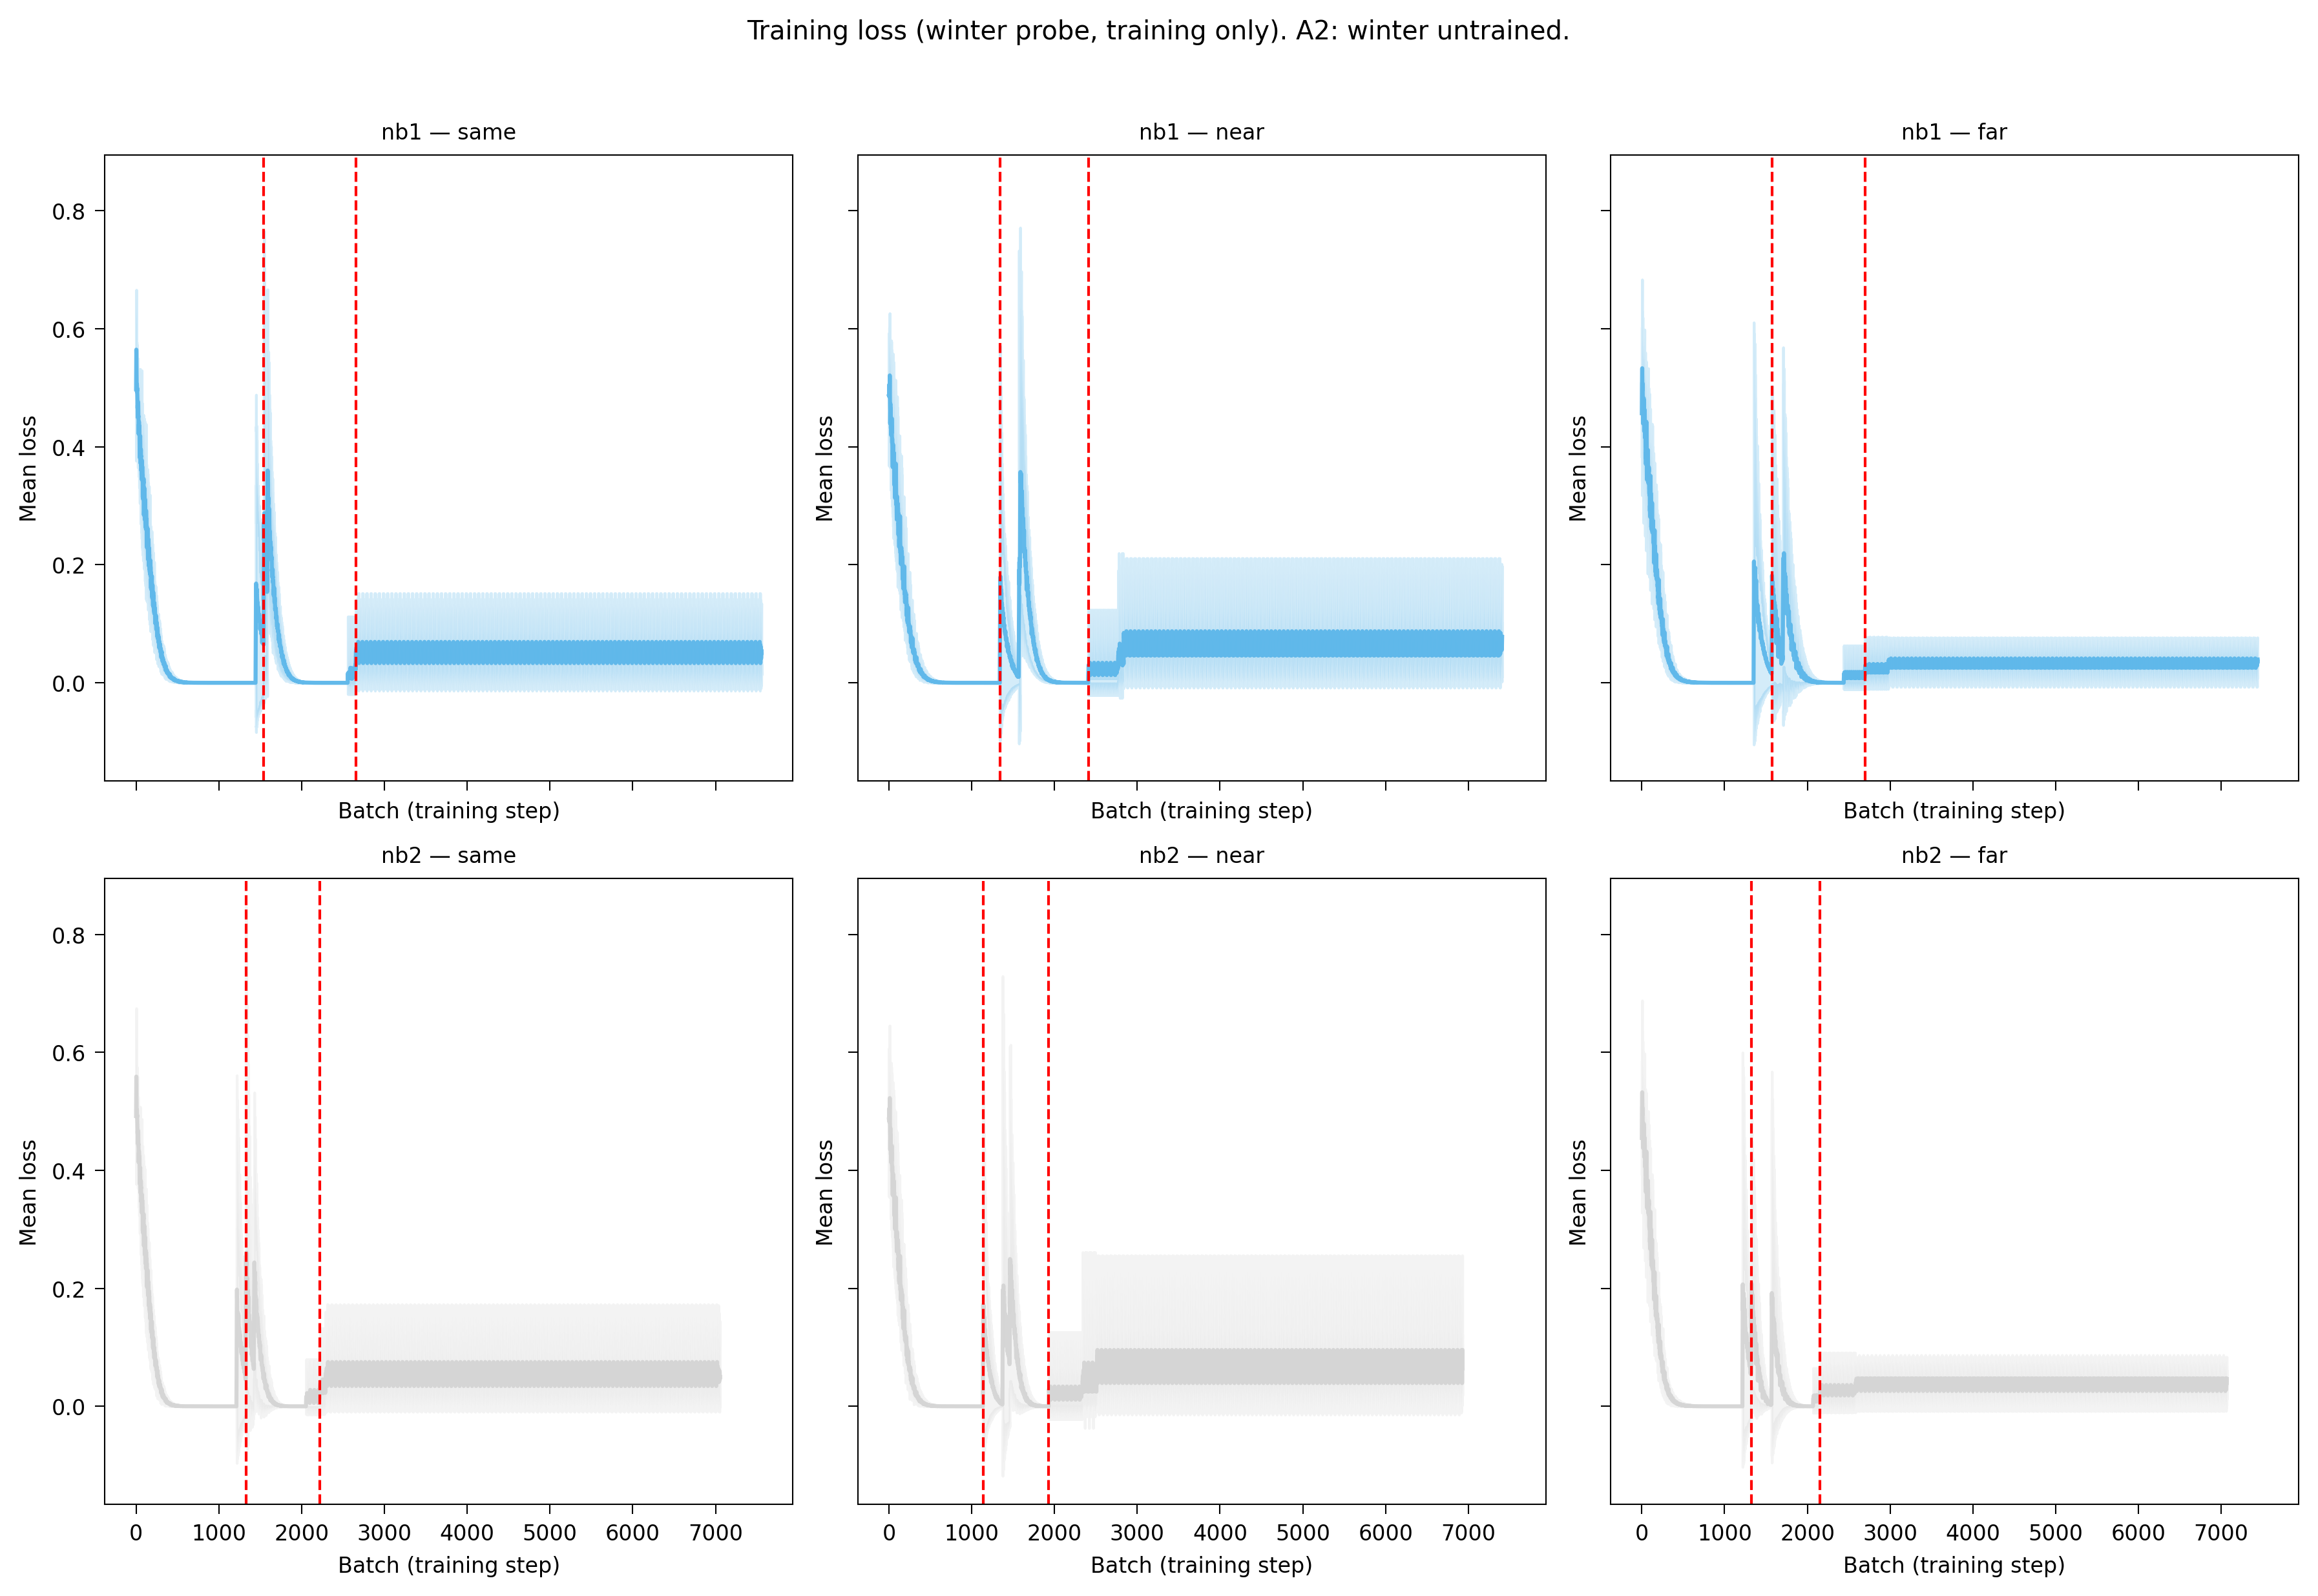

In [9]:
if loss_results:
    run_labels = ["nb1", "nb2"]
    schedules = ["same", "near", "far"]
    nrows, ncols = len(run_labels), len(schedules)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharex=True, sharey=True)
    if nrows == 1:
        axes = axes[np.newaxis, :]
    if ncols == 1:
        axes = axes[:, np.newaxis]
    smooth_window = 5
    for r, run_label in enumerate(run_labels):
        for c, sched in enumerate(schedules):
            ax = axes[r, c]
            if run_label not in loss_results or sched not in loss_results[run_label]:
                ax.set_visible(False)
                continue
            loss = loss_results[run_label][sched]
            mean_loss = np.asarray(loss["mean"])
            std_loss = loss.get("std", np.zeros_like(mean_loss))
            steps = np.arange(len(mean_loss))
            smooth_mean = pd.Series(mean_loss).rolling(window=smooth_window, center=True, min_periods=1).mean().to_numpy()
            color = "#56B4E9" if run_label == "nb1" else "lightgray"
            if np.any(np.isfinite(std_loss)) and np.any(std_loss > 0):
                ax.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.25)
            ax.plot(steps, smooth_mean, color=color, linewidth=1.5, alpha=0.9)
            bounds = loss.get("phase_boundaries")
            if bounds is not None:
                for x in bounds:
                    ax.axvline(x, color="red", linestyle="--", linewidth=1)
            ax.set_xlabel("Batch (training step)")
            ax.set_ylabel("Mean loss")
            ax.set_title(f"{run_label} — {sched}")
    fig.suptitle("Training loss (winter probe, training only). A2: winter untrained.", y=1.02)
    fig.tight_layout()
    plt.show()

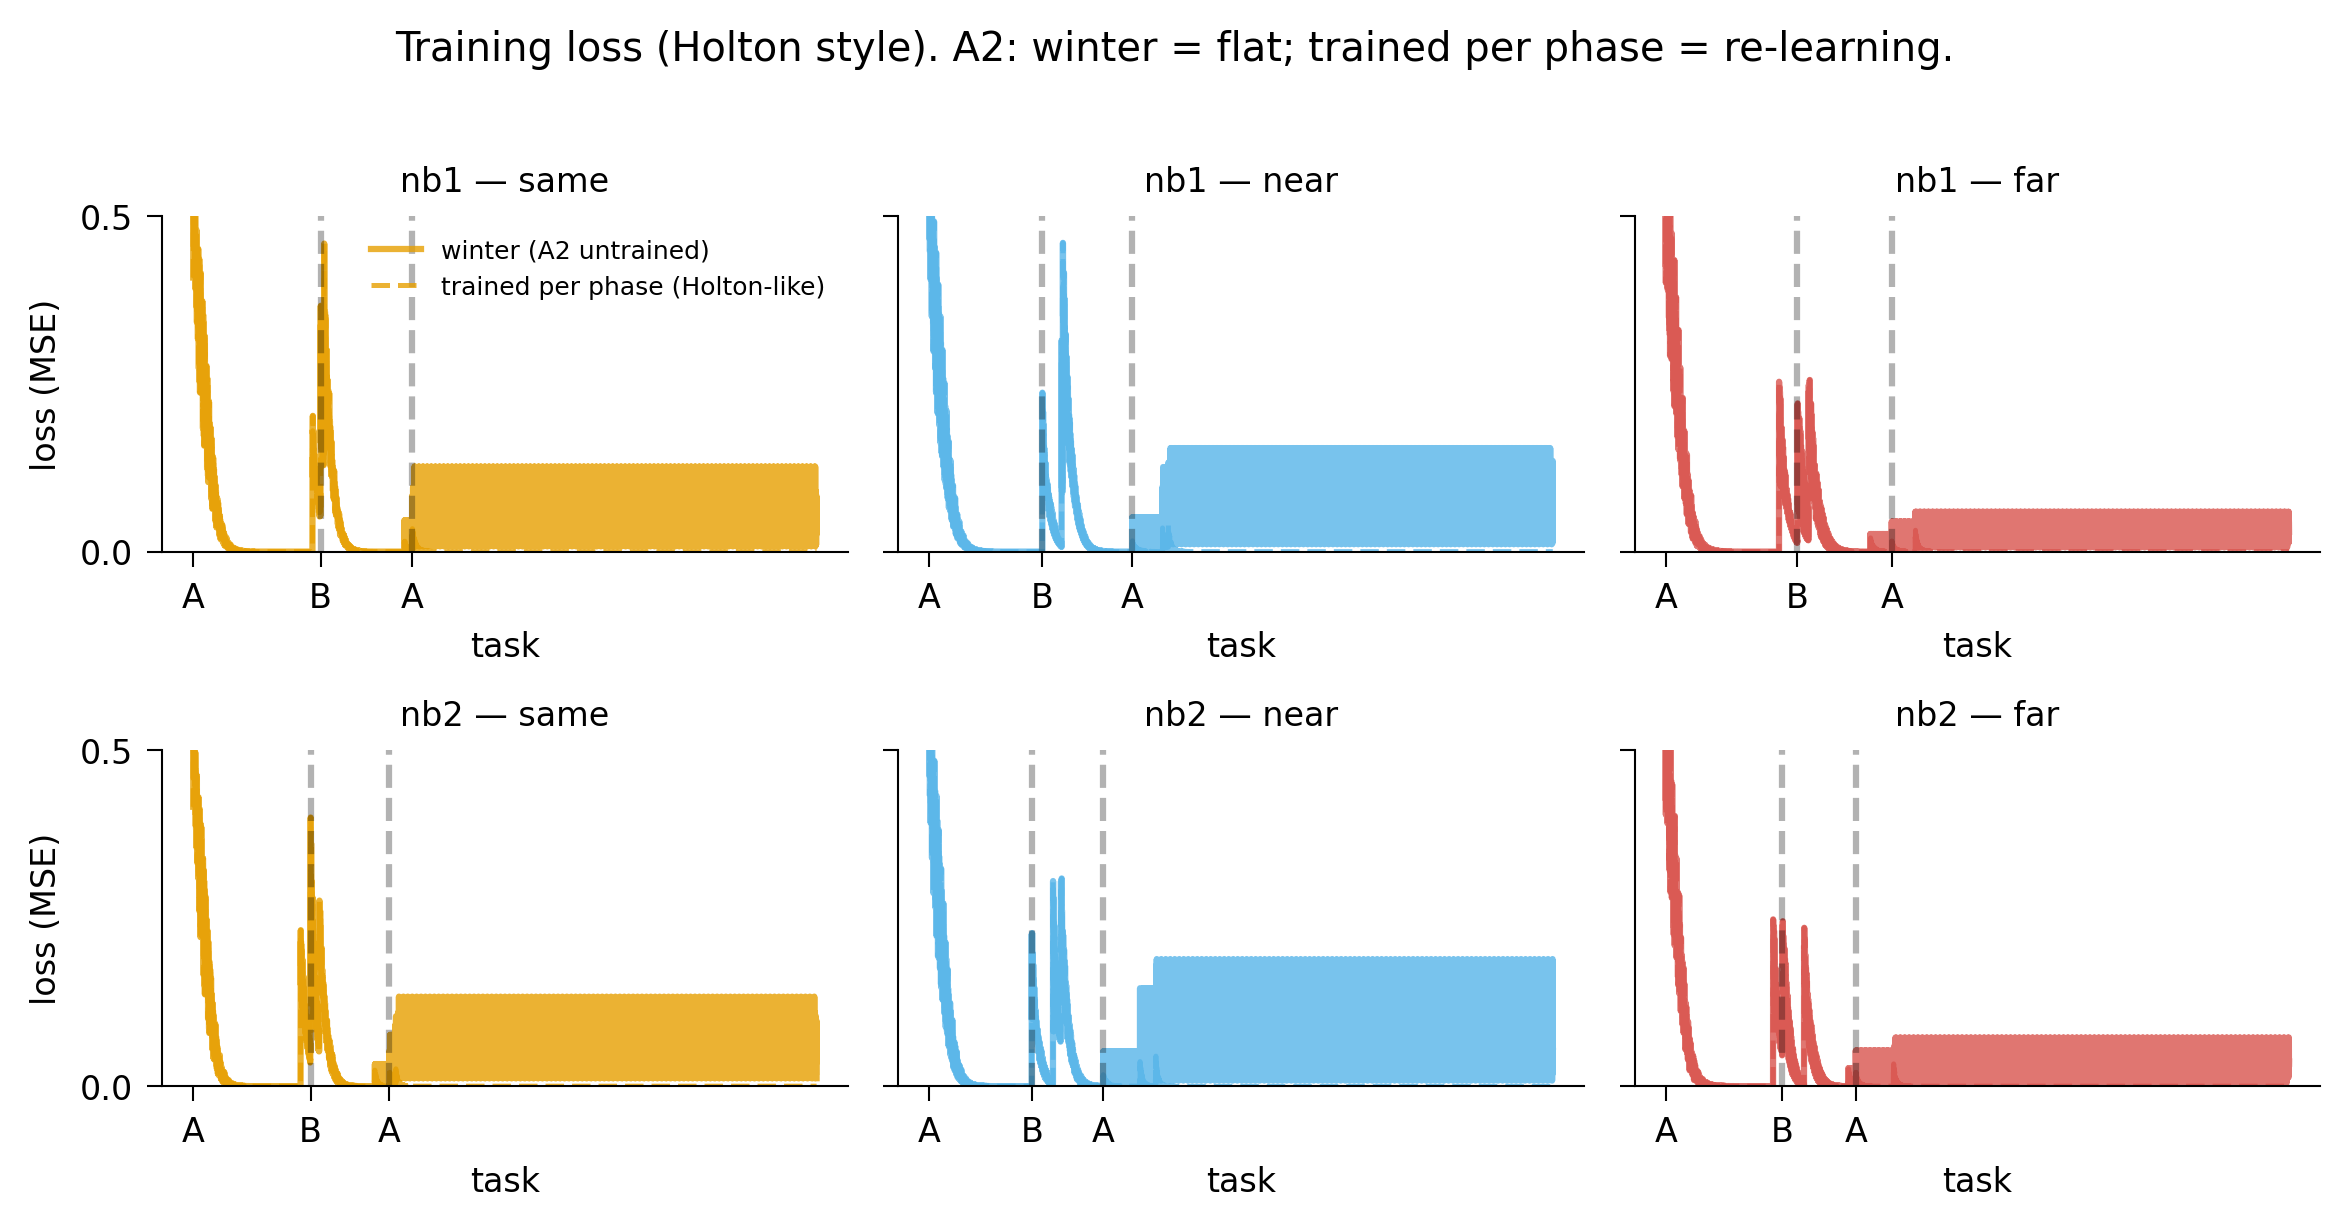

In [10]:
# Loss curves — Holton style: y 0–0.5, phase labels A/B/A. Solid: winter (A2 untrained); dashed: trained per phase (A2 re-learning).
if loss_results:
    from a1b2.utils.figure_utils import _style_axes
    from a1b2.utils.figure_settings import cm_conv
    run_labels = ["nb1", "nb2"]
    schedules = ["same", "near", "far"]
    fig, axes = plt.subplots(2, 3, figsize=(20 * cm_conv, 10 * cm_conv), sharey=True, sharex=False)
    for r, run_label in enumerate(run_labels):
        for c, sched in enumerate(schedules):
            ax = axes[r, c]
            if run_label not in loss_results or sched not in loss_results[run_label]:
                ax.set_visible(False)
                continue
            loss = loss_results[run_label][sched]
            mean_loss = np.asarray(loss["mean"])
            steps = np.arange(len(mean_loss))
            bounds = loss.get("phase_boundaries")
            color = schedule_colours[c]
            ax.plot(steps, mean_loss, color=color, alpha=0.8, linewidth=1.5, label="winter (A2 untrained)" if (r, c) == (0, 0) else None)
            if loss_results_holton and run_label in loss_results_holton and sched in loss_results_holton[run_label]:
                h = loss_results_holton[run_label][sched]
                m = np.asarray(h["mean"])
                n = min(len(m), len(steps))
                ax.plot(steps[:n], m[:n], color=color, linestyle="--", alpha=0.8, linewidth=1.2, label="trained per phase (Holton-like)" if (r, c) == (0, 0) else None)
            if bounds is not None:
                ax.axvline(bounds[0], color="k", linestyle="--", alpha=0.3)
                ax.axvline(bounds[1], color="k", linestyle="--", alpha=0.3)
                ax.set_xticks([0, bounds[0], bounds[1]])
                ax.set_xticklabels(["A", "B", "A"])
            ax.set_ylim(0, 0.5)
            ax.set_yticks([0, 0.5])
            ax.set_xlabel("task")
            ax.set_ylabel("loss (MSE)" if c == 0 else "")
            ax.set_title(f"{run_label} — {sched}")
            _style_axes(ax)
    if loss_results_holton:
        axes[0, 0].legend(fontsize=6)
    fig.suptitle("Training loss (Holton style). A2: winter = flat; trained per phase = re-learning.", y=1.02)
    fig.tight_layout()
    plt.show()

### Training loss — trained per phase only (Holton-like)

Same 2×3 grid showing only the **trained feature per phase** (winter in A1/B, summer in A2). A2 curve descends (re-learning); matches Holton’s [1::2] interpretation.

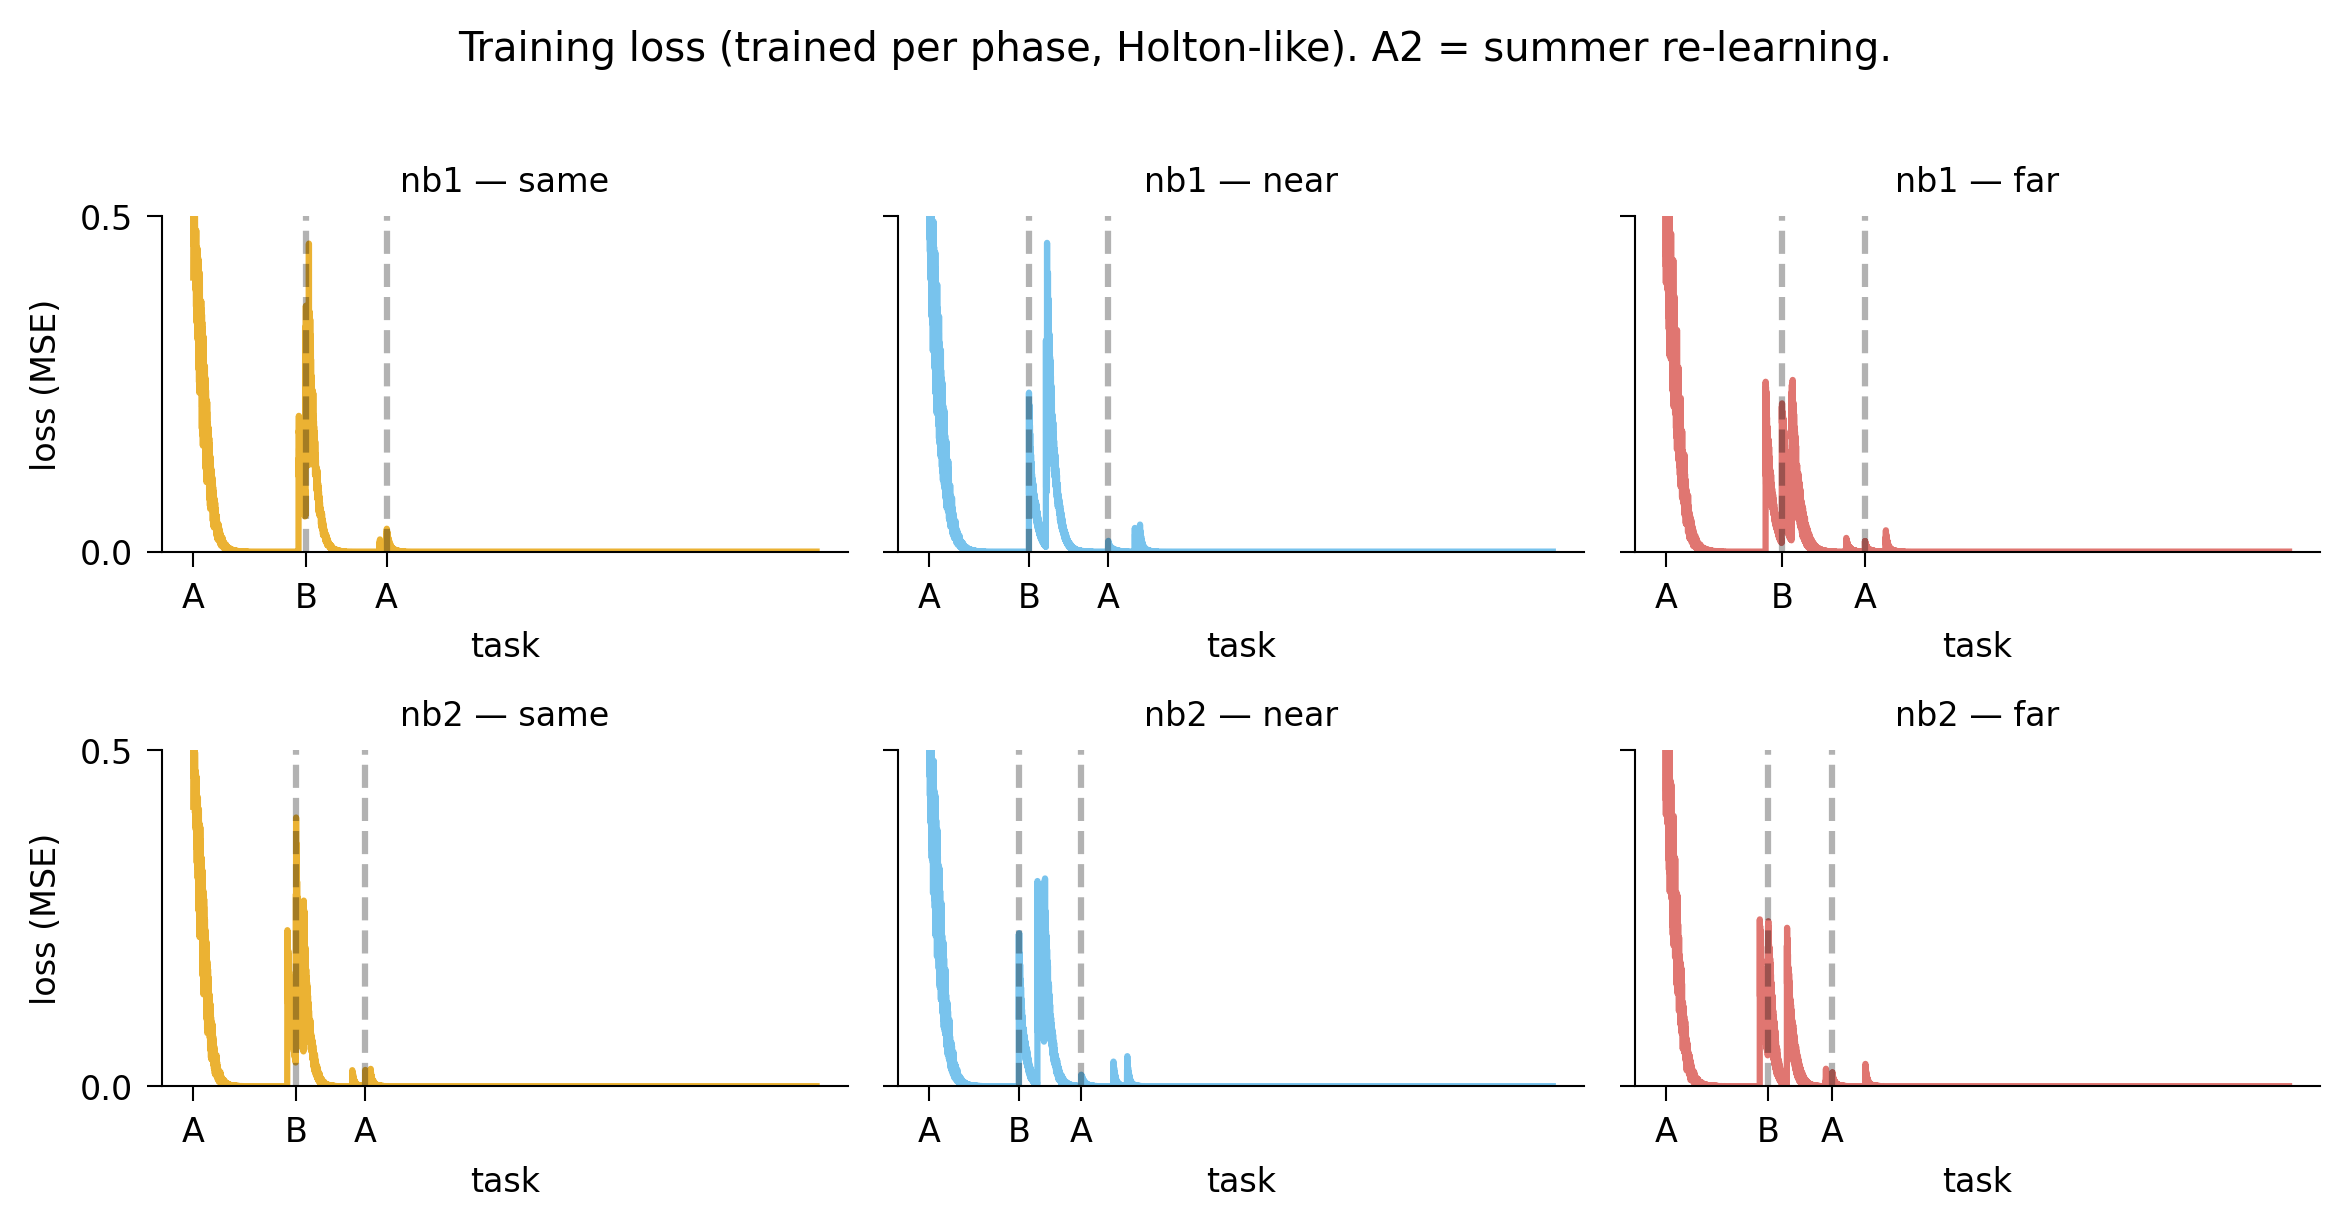

In [11]:
# Holton-like: trained per phase only (A2 = summer → re-learning)
if loss_results_holton:
    from a1b2.utils.figure_utils import _style_axes
    from a1b2.utils.figure_settings import cm_conv
    run_labels = ["nb1", "nb2"]
    schedules = ["same", "near", "far"]
    fig, axes = plt.subplots(2, 3, figsize=(20 * cm_conv, 10 * cm_conv), sharey=True, sharex=False)
    for r, run_label in enumerate(run_labels):
        for c, sched in enumerate(schedules):
            ax = axes[r, c]
            if run_label not in loss_results_holton or sched not in loss_results_holton[run_label]:
                ax.set_visible(False)
                continue
            loss = loss_results_holton[run_label][sched]
            mean_loss = np.asarray(loss["mean"])
            steps = np.arange(len(mean_loss))
            bounds = loss.get("phase_boundaries")
            color = schedule_colours[c]
            ax.plot(steps, mean_loss, color=color, alpha=0.8, linewidth=1.5)
            if bounds is not None:
                ax.axvline(bounds[0], color="k", linestyle="--", alpha=0.3)
                ax.axvline(bounds[1], color="k", linestyle="--", alpha=0.3)
                ax.set_xticks([0, bounds[0], bounds[1]])
                ax.set_xticklabels(["A", "B", "A"])
            ax.set_ylim(0, 0.5)
            ax.set_yticks([0, 0.5])
            ax.set_xlabel("task")
            ax.set_ylabel("loss (MSE)" if c == 0 else "")
            ax.set_title(f"{run_label} — {sched}")
            _style_axes(ax)
    fig.suptitle("Training loss (trained per phase, Holton-like). A2 = summer re-learning.", y=1.02)
    fig.tight_layout()
    plt.show()

### A2 loss summary (winter probe)

Mean (SEM) loss at **start of A2** (first batch) and **end of A2** (last 5 batches) by schedule and run. Winter probe: A2 start is post-B, end is after re-exposure to A.

In [ ]:
# A2 loss: start (first batch) and end (mean of last 5 batches), winter probe
if loss_results:
    rows = []
    for run_label in ["nb1", "nb2"]:
        if run_label not in loss_results:
            continue
        for sched in ["same", "near", "far"]:
            if sched not in loss_results[run_label]:
                continue
            loss = loss_results[run_label][sched]
            mean_loss = np.asarray(loss["mean"])
            bounds = loss.get("phase_boundaries")
            if bounds is None or bounds[1] >= len(mean_loss):
                continue
            b2 = int(bounds[1])
            start_a2 = mean_loss[b2]
            end_a2 = np.mean(mean_loss[max(b2, len(mean_loss) - 5) :])
            rows.append({"run": run_label, "schedule": sched, "A2_start": start_a2, "A2_end": end_a2})
    if rows:
        a2_df = pd.DataFrame(rows)
        print(a2_df.to_string(index=False))

run schedule  A2_start   A2_end
nb1     same  0.063393 0.048864
nb1     near  0.021675 0.063897
nb1      far  0.044731 0.038385
nb2     same  0.052599 0.052235
nb2     near  0.023538 0.087144
nb2      far  0.053187 0.043218


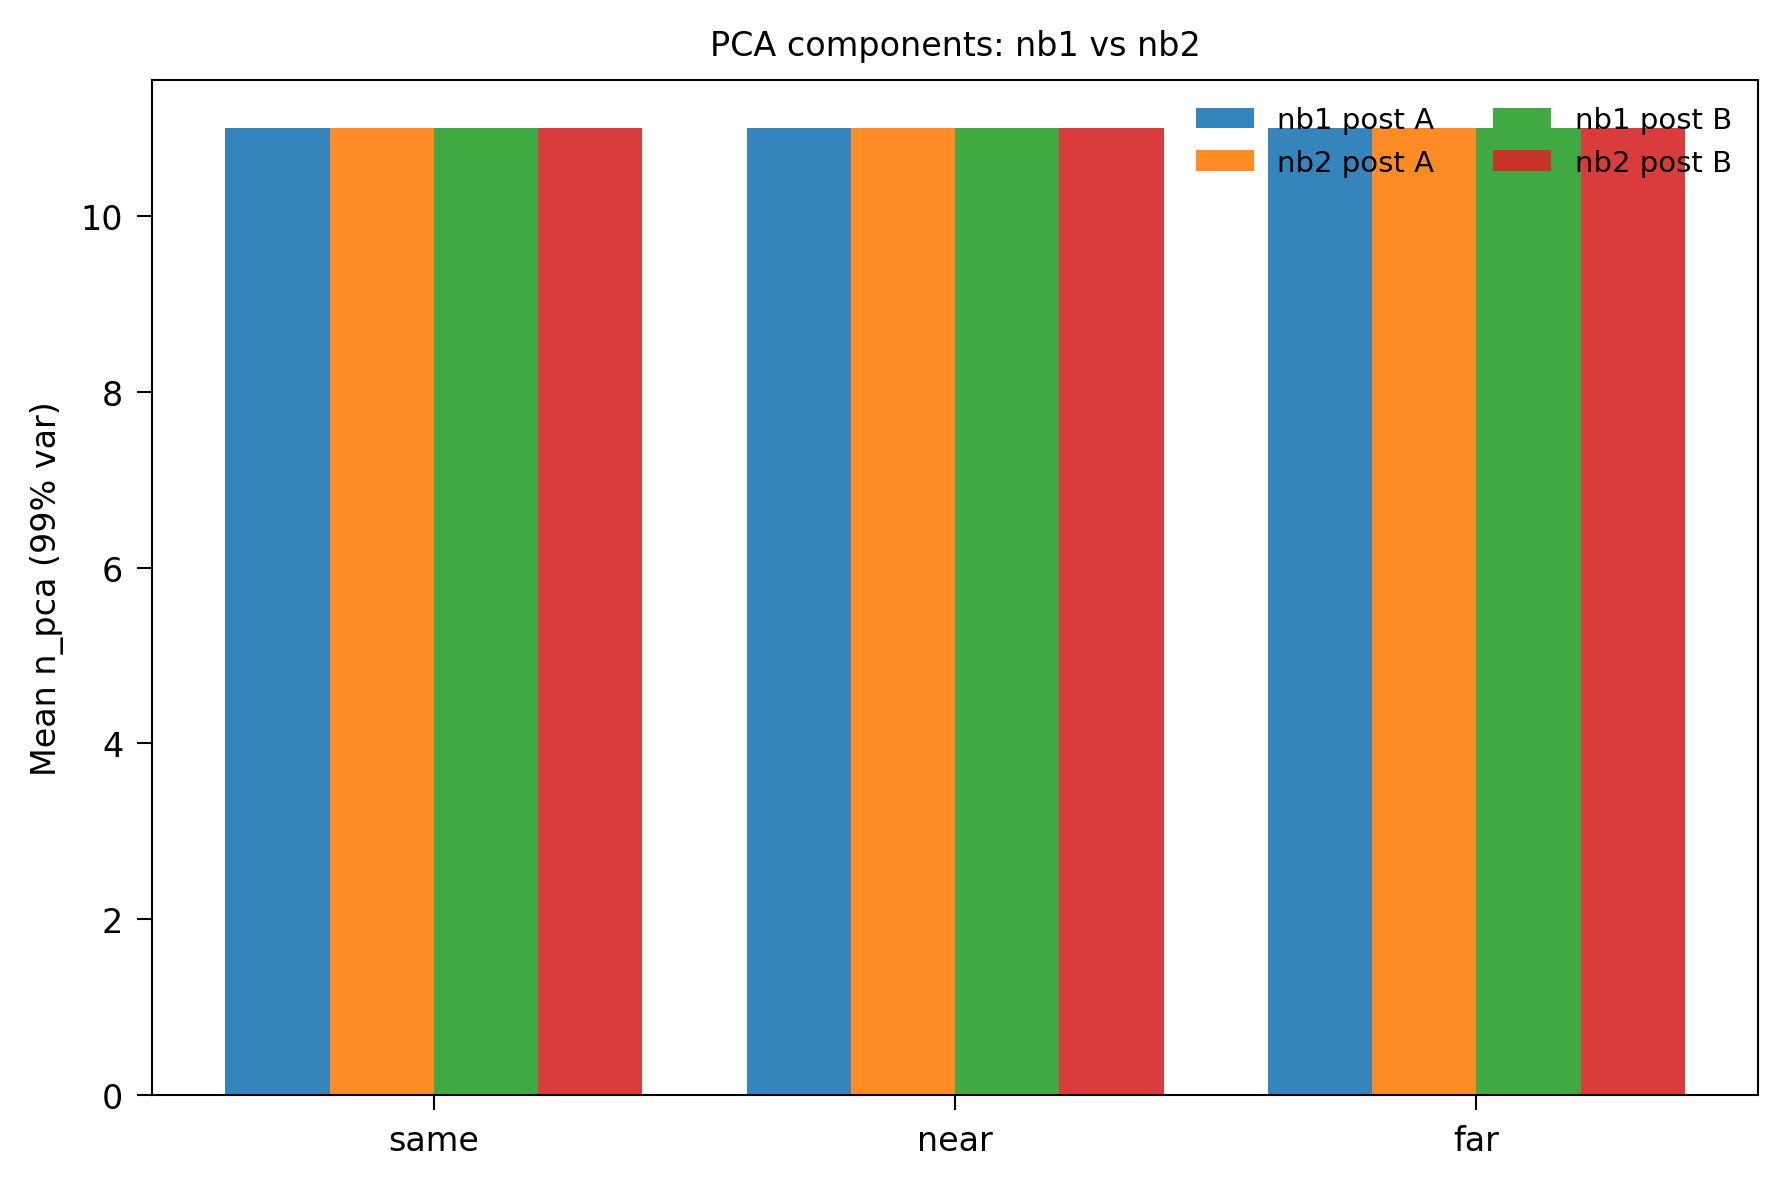

In [13]:
if not pca_all.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    pca_agg = pca_all.groupby(["run_label", "condition", "task"], as_index=False)["n_pca"].mean()
    x = np.arange(len(condition_order))
    w = 0.2
    for ti, task in enumerate(["post A", "post B"]):
        for ri, run_label in enumerate(["nb1", "nb2"]):
            sub = pca_agg[(pca_agg["run_label"] == run_label) & (pca_agg["task"] == task)]
            means = [sub[(sub["condition"] == s)]["n_pca"].values for s in condition_order]
            means = [float(m[0]) if len(m) else np.nan for m in means]
            off = (ti - 0.5) * 2 * w + (ri - 0.5) * w
            ax.bar(x + off, means, w, label=f"{run_label} {task}", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Mean n_pca (99% var)")
    ax.legend(ncol=2, fontsize=7)
    ax.set_title("PCA components: nb1 vs nb2")
    fig.tight_layout()
    plt.show()

### PCA 2D (post-A and post-B hiddens, by configuration)

Holton-style comparison: two figures showing 2D PCA of hidden layer stimuli representations—one after **phase A** and one after **phase B**. Each figure has one subplot per (run × schedule). Points colored by task (A vs B stimuli).

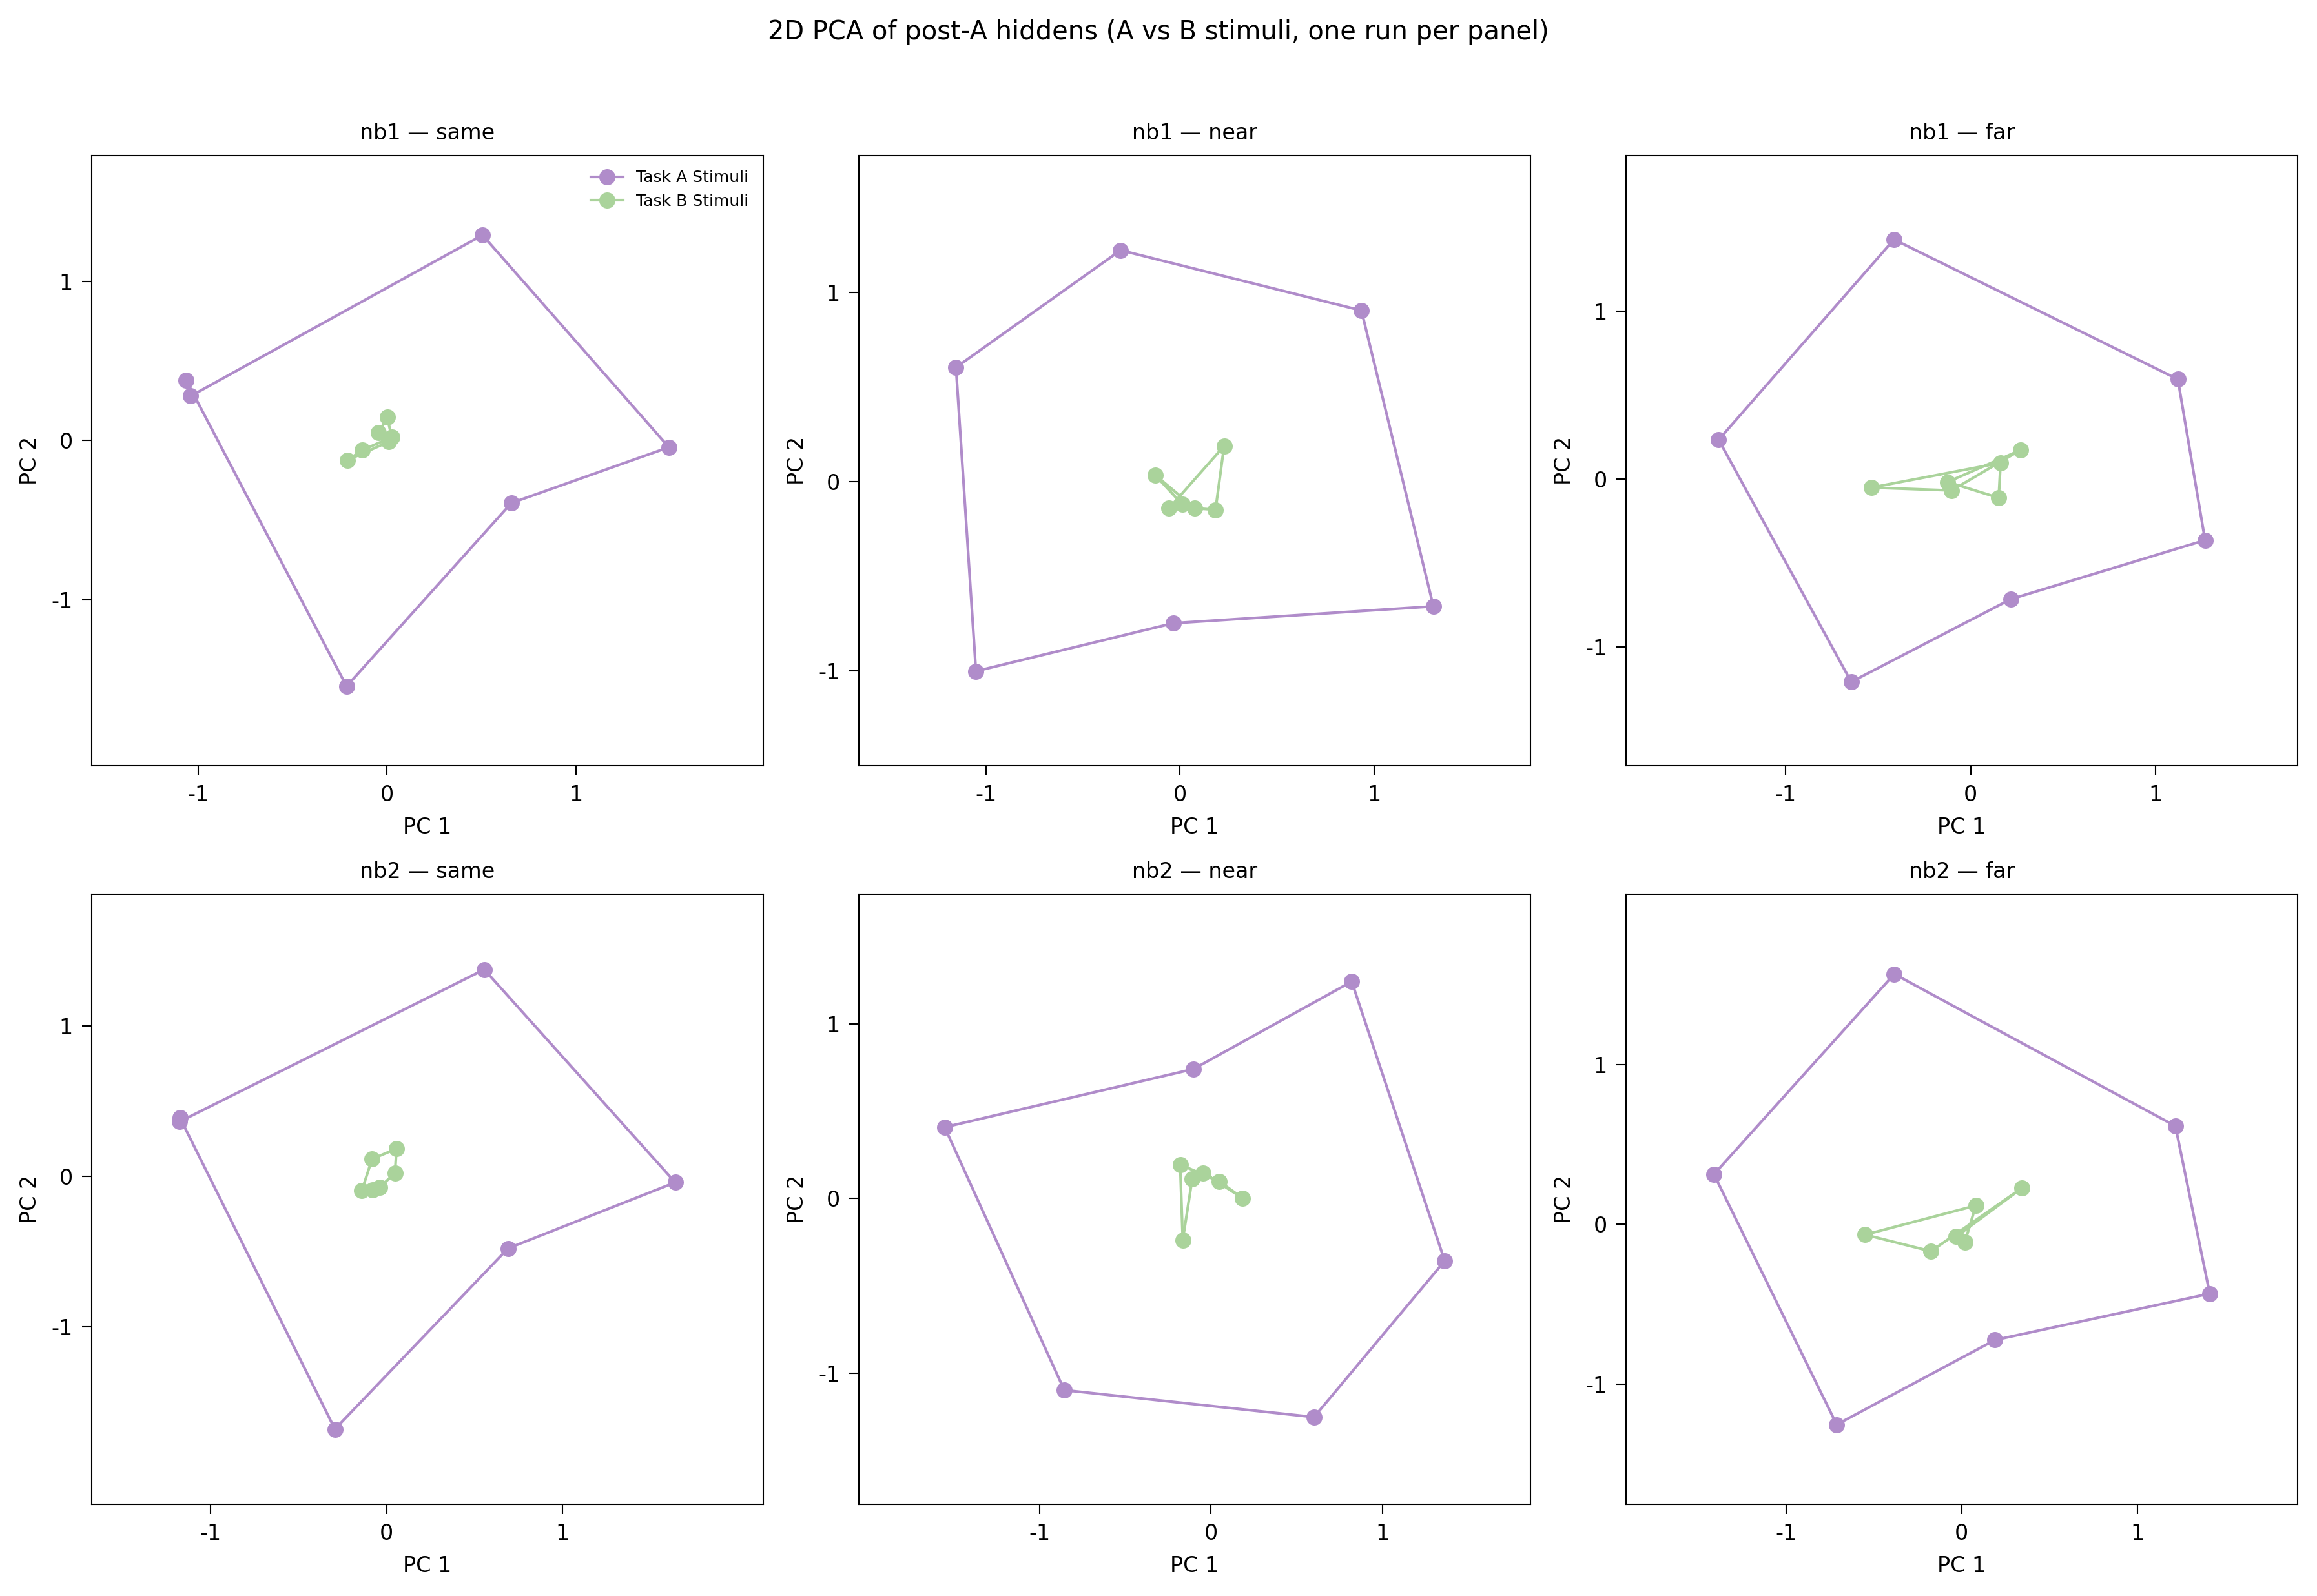

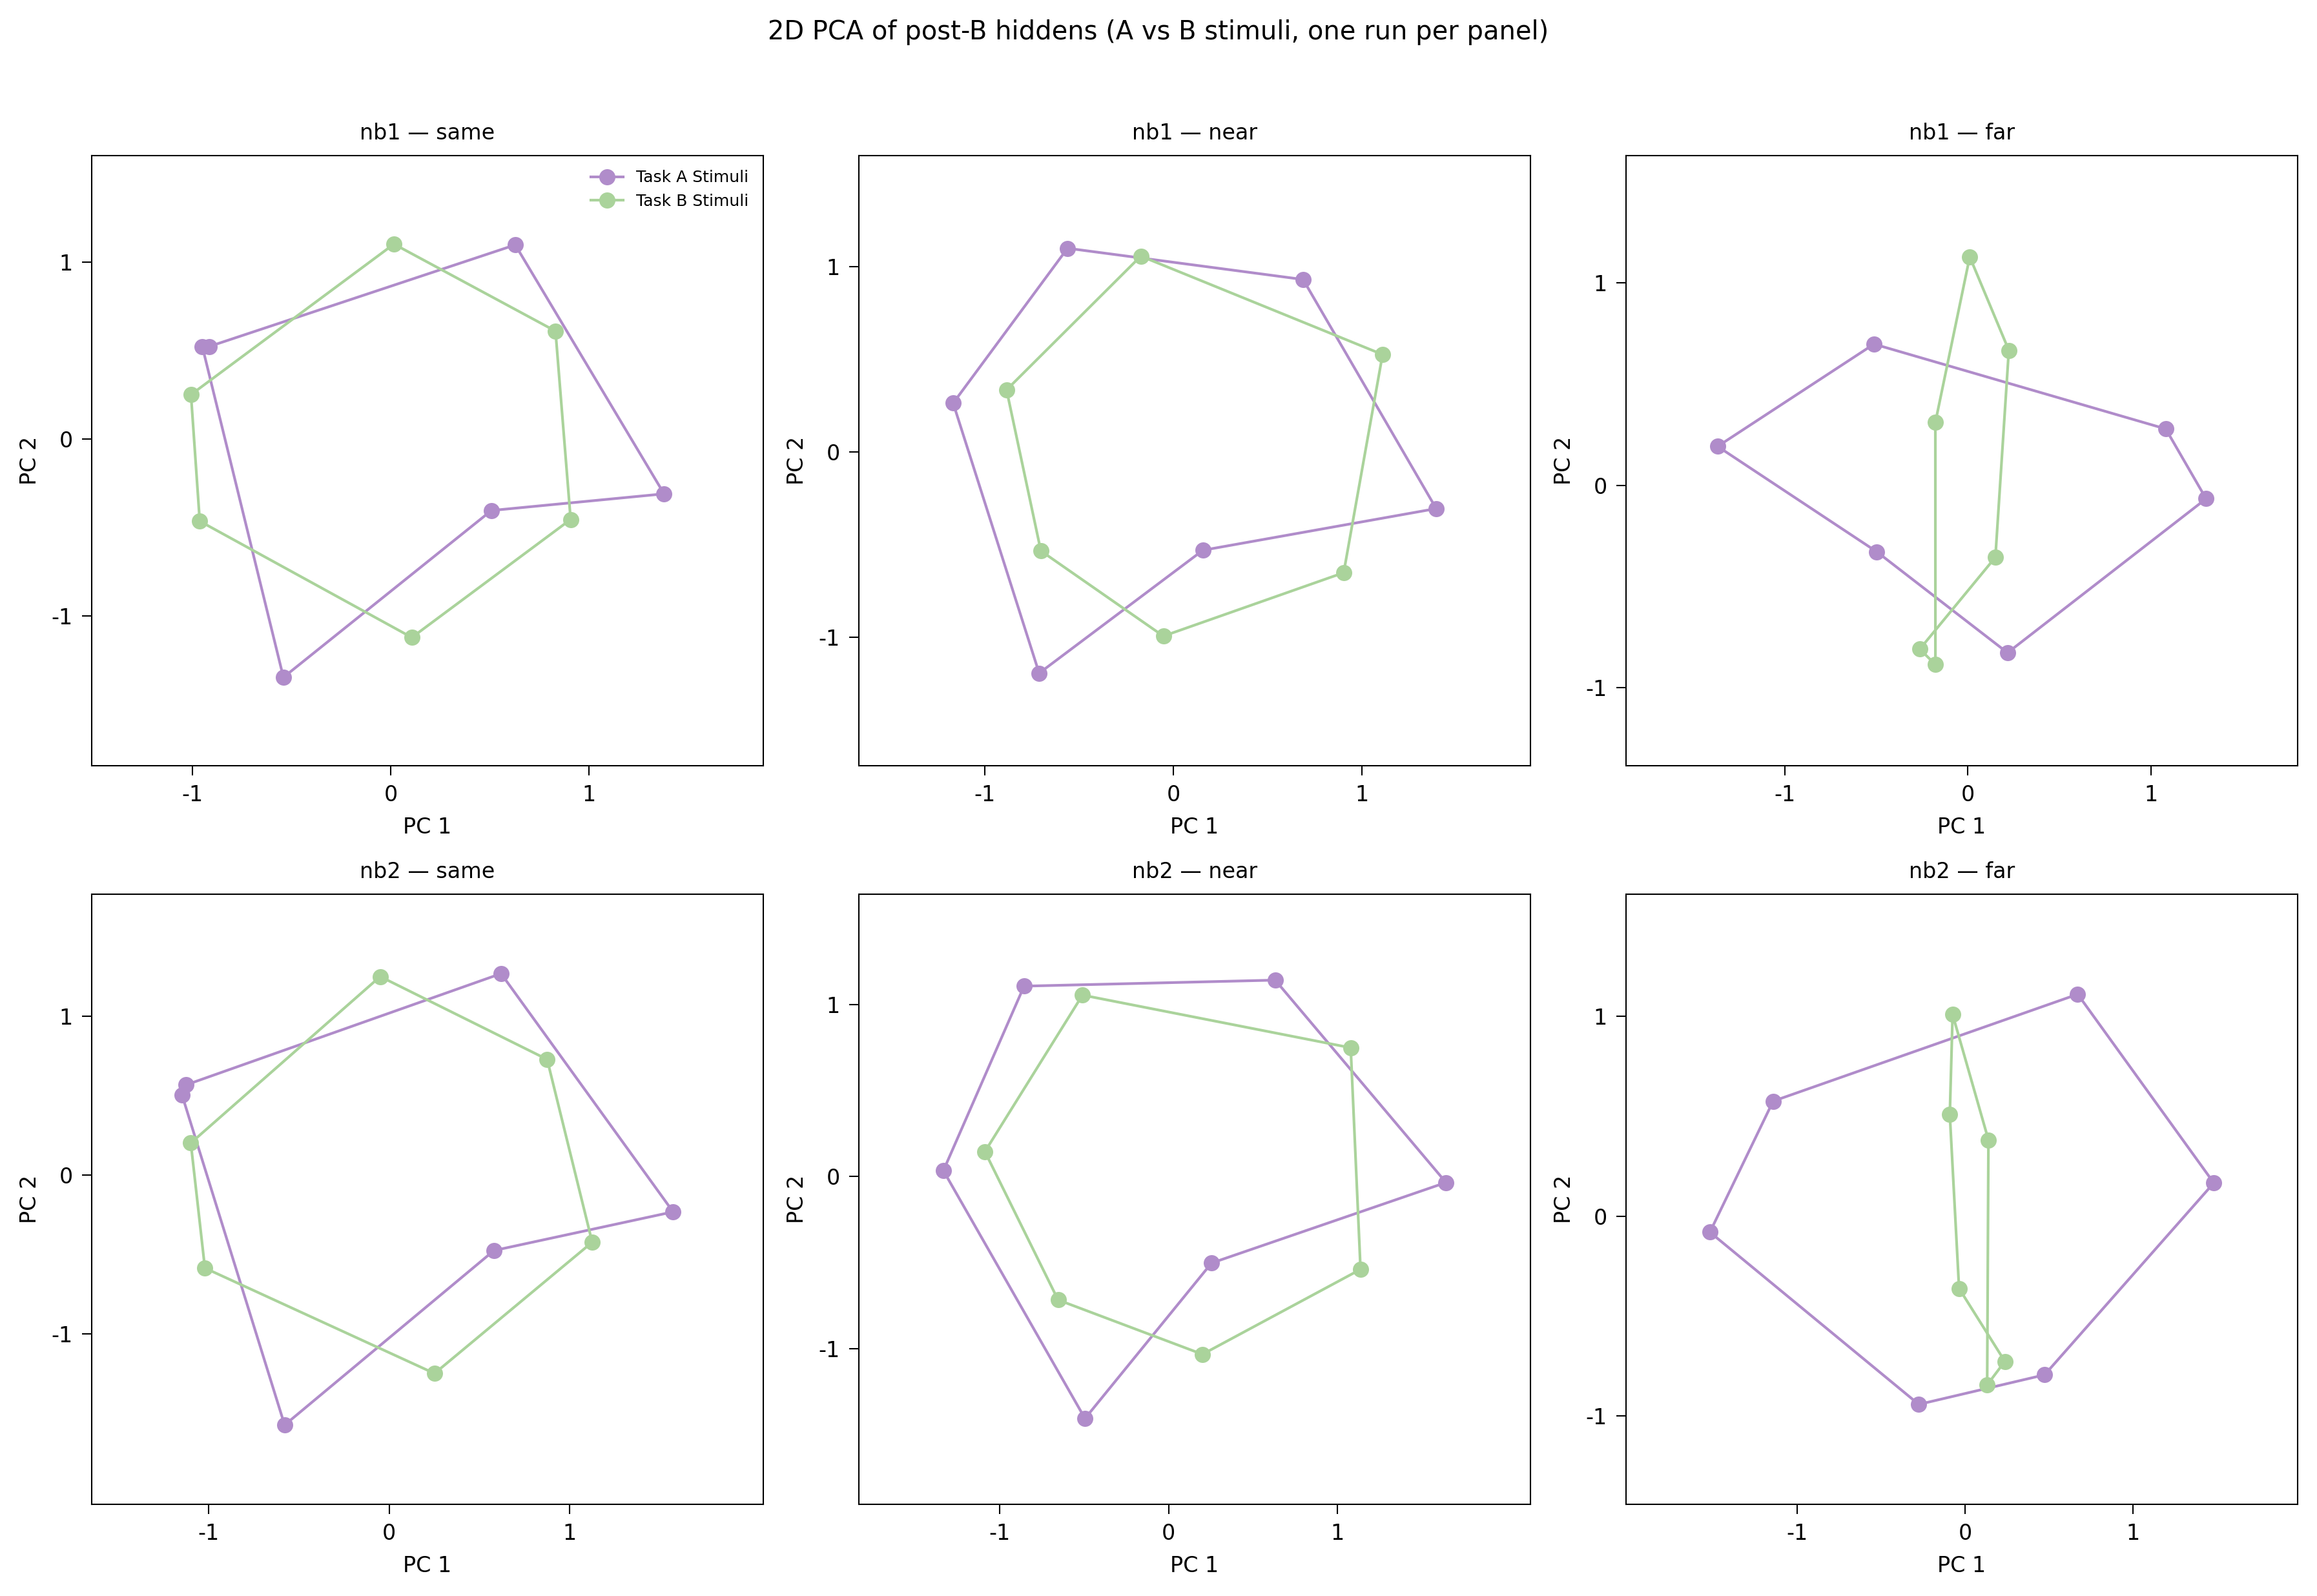

In [14]:
# 2D PCA of hidden layer stimuli (Holton-style, one run per subplot): post-A and post-B
# Uses transfer_interference method: single participant per panel, prepare_pca_single_task + plot_split_stim (hexagons)
from a1b2.utils.figure_settings import task_colours
from a1b2.utils import figure_utils

run_labels = ["nb1", "nb2"]
schedules = ["same", "near", "far"]
schedule_to_idx = {"same": 0, "near": 1, "far": 2}
# Which participant to show per (run_label, schedule): first (index 0), matching geometry-style one-run-per-panel
SUBJ_IDX = 0

def get_hiddens_12(h, sched):
    """Return (12, dim) for this schedule. Handles (3, 12, dim) or (12, dim)."""
    if h is None or not hasattr(h, "shape"):
        return None
    if h.ndim == 3 and h.shape[0] == 3 and h.shape[1] >= 12:
        return h[schedule_to_idx[sched], :12, :]
    if h.ndim == 2 and len(h) >= 12:
        return h[:12]
    return None

if all_ann_data:
    for phase_key, phase_title in [("hiddens_post_phase_0", "post-A"), ("hiddens_post_phase_1", "post-B")]:
        fig, axes = plt.subplots(2, 3, figsize=(4 * 3, 4 * 2), sharex=False, sharey=False)
        if axes.ndim == 1:
            axes = axes.reshape(1, -1)
        for r, run_label in enumerate(run_labels):
            if run_label not in all_ann_data:
                continue
            data = all_ann_data[run_label]
            for c, sched in enumerate(schedules):
                ax = axes[r, c]
                if sched not in data or len(data[sched]) == 0:
                    ax.set_visible(False)
                    continue
                subj = min(SUBJ_IDX, len(data[sched]) - 1)
                h = data[sched][subj].get(phase_key)
                h12 = get_hiddens_12(h, sched)
                if h12 is None:
                    ax.set_visible(False)
                    continue
                pca, transformed = ann.prepare_pca_single_task(h12)
                lims = figure_utils.get_axis_limits(transformed)
                figure_utils.plot_split_stim(ax, transformed, task_colours, lims)
                ax.set_title(f"{run_label} — {sched}")
                if r == 0 and c == 0:
                    ax.legend(fontsize=6)
        fig.suptitle(f"2D PCA of {phase_title} hiddens (A vs B stimuli, one run per panel)", y=1.02)
        fig.tight_layout()
        plt.show()

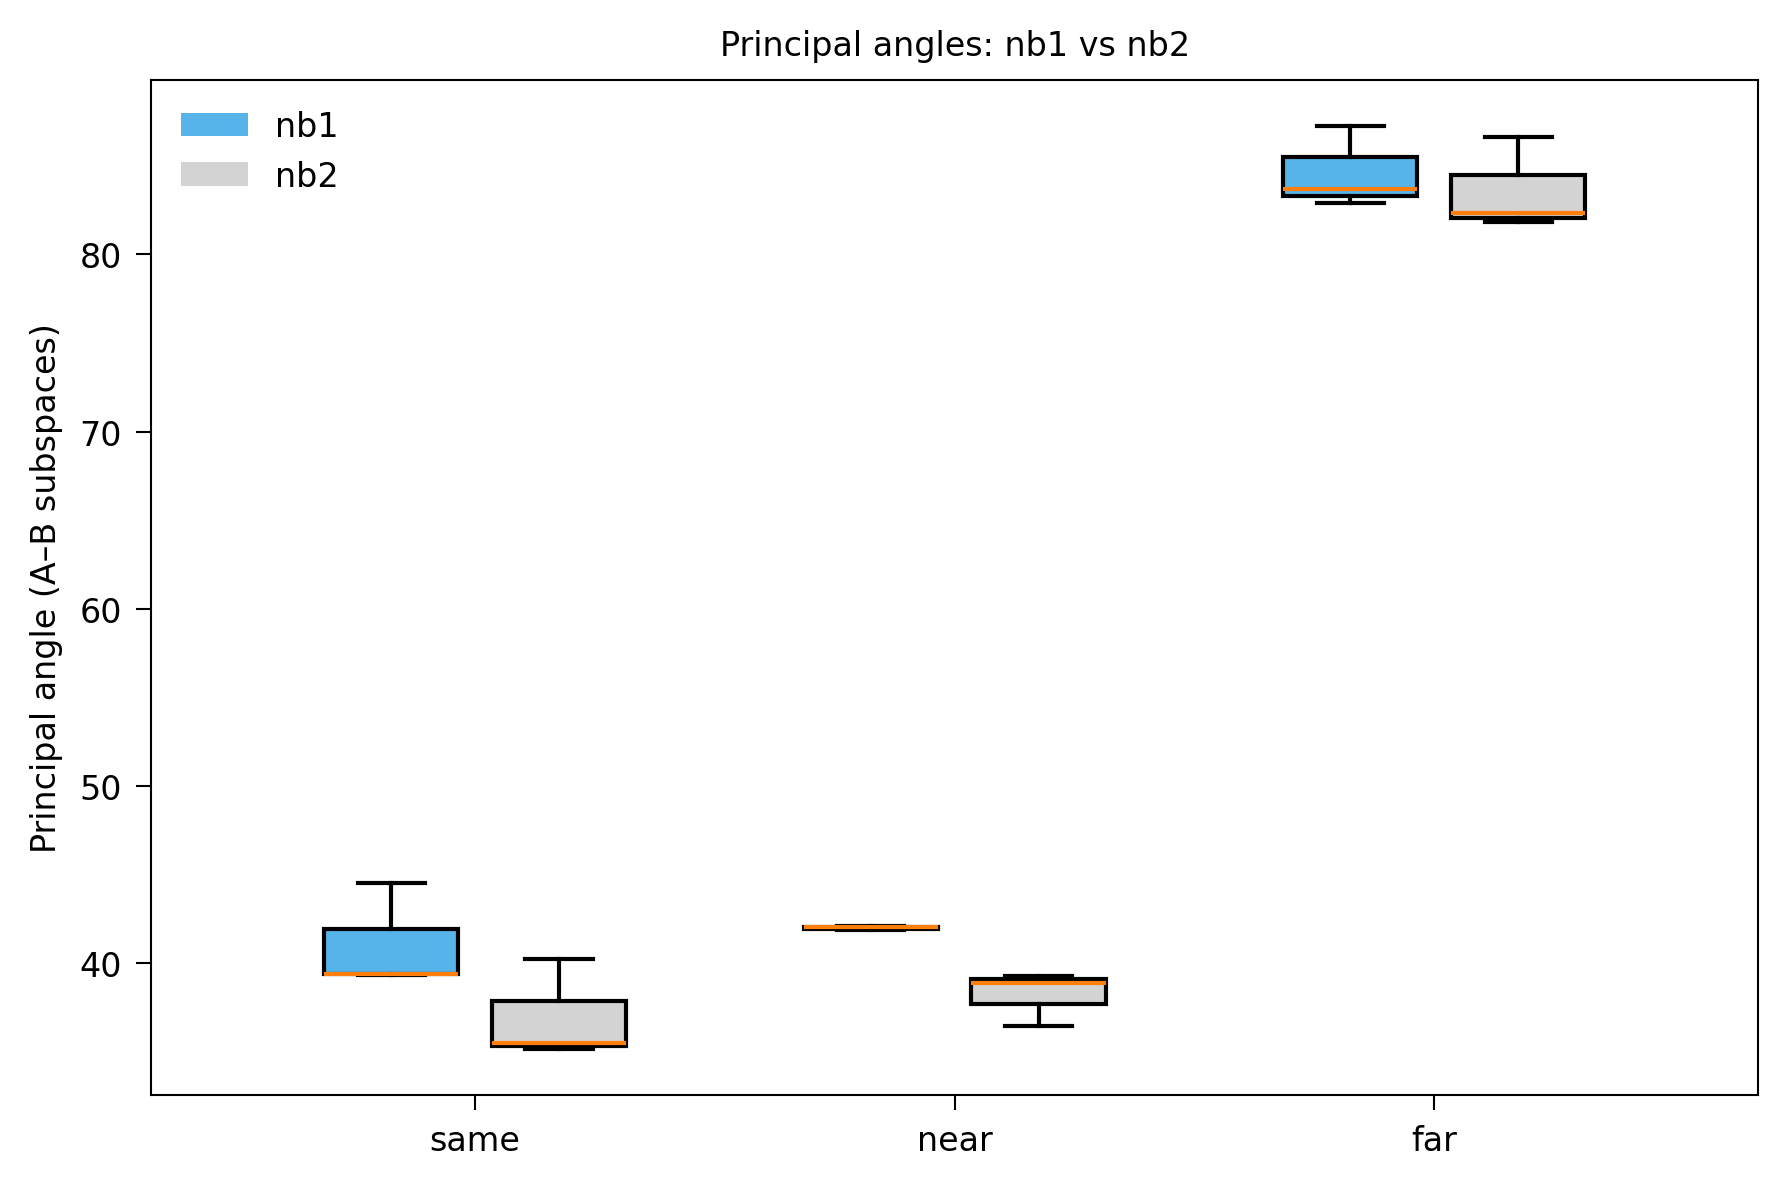

In [15]:
try:
    _ = angles_all
except NameError:
    angles_all = pd.DataFrame()
if not angles_all.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    positions = np.arange(len(condition_order))
    width = 0.35
    for ri, run_label in enumerate(["nb1", "nb2"]):
        sub = angles_all[angles_all["run_label"] == run_label]
        if sub.empty:
            continue
        data_by_cond = [sub[sub["condition"] == s]["principal_angle_between"].values for s in condition_order]
        data_by_cond = [d for d in data_by_cond if len(d) > 0]
        if not data_by_cond:
            continue
        pos = positions + (ri - 0.5) * width
        bp = ax.boxplot(data_by_cond, positions=pos, widths=width * 0.8, patch_artist=True)
        color = "#56B4E9" if run_label == "nb1" else "lightgray"
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
    ax.set_xticks(positions)
    ax.set_xticklabels(condition_order)
    ax.set_ylabel("Principal angle (A–B subspaces)")
    ax.set_title("Principal angles: nb1 vs nb2")
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor="#56B4E9", label="nb1"), Patch(facecolor="lightgray", label="nb2")]
    ax.legend(handles=legend_handles)
    fig.tight_layout()
    plt.show()

### 5b. Sanity: nb2 trajectory data

Check that nb2 run contains trajectory (or per-module) keys; optionally plot 2D PCA of one trajectory.

nb2 RNN-extra keys (trajectory/per_module): ['hiddens_per_module', 'hiddens_post_phase_0_trajectory', 'hiddens_post_phase_1_trajectory', 'hiddens_post_phase_2_trajectory', 'hiddens_post_phase_0_per_module', 'hiddens_post_phase_1_per_module', 'hiddens_post_phase_2_per_module']
  hiddens_post_phase_0_trajectory shape: (2, 12, 100)


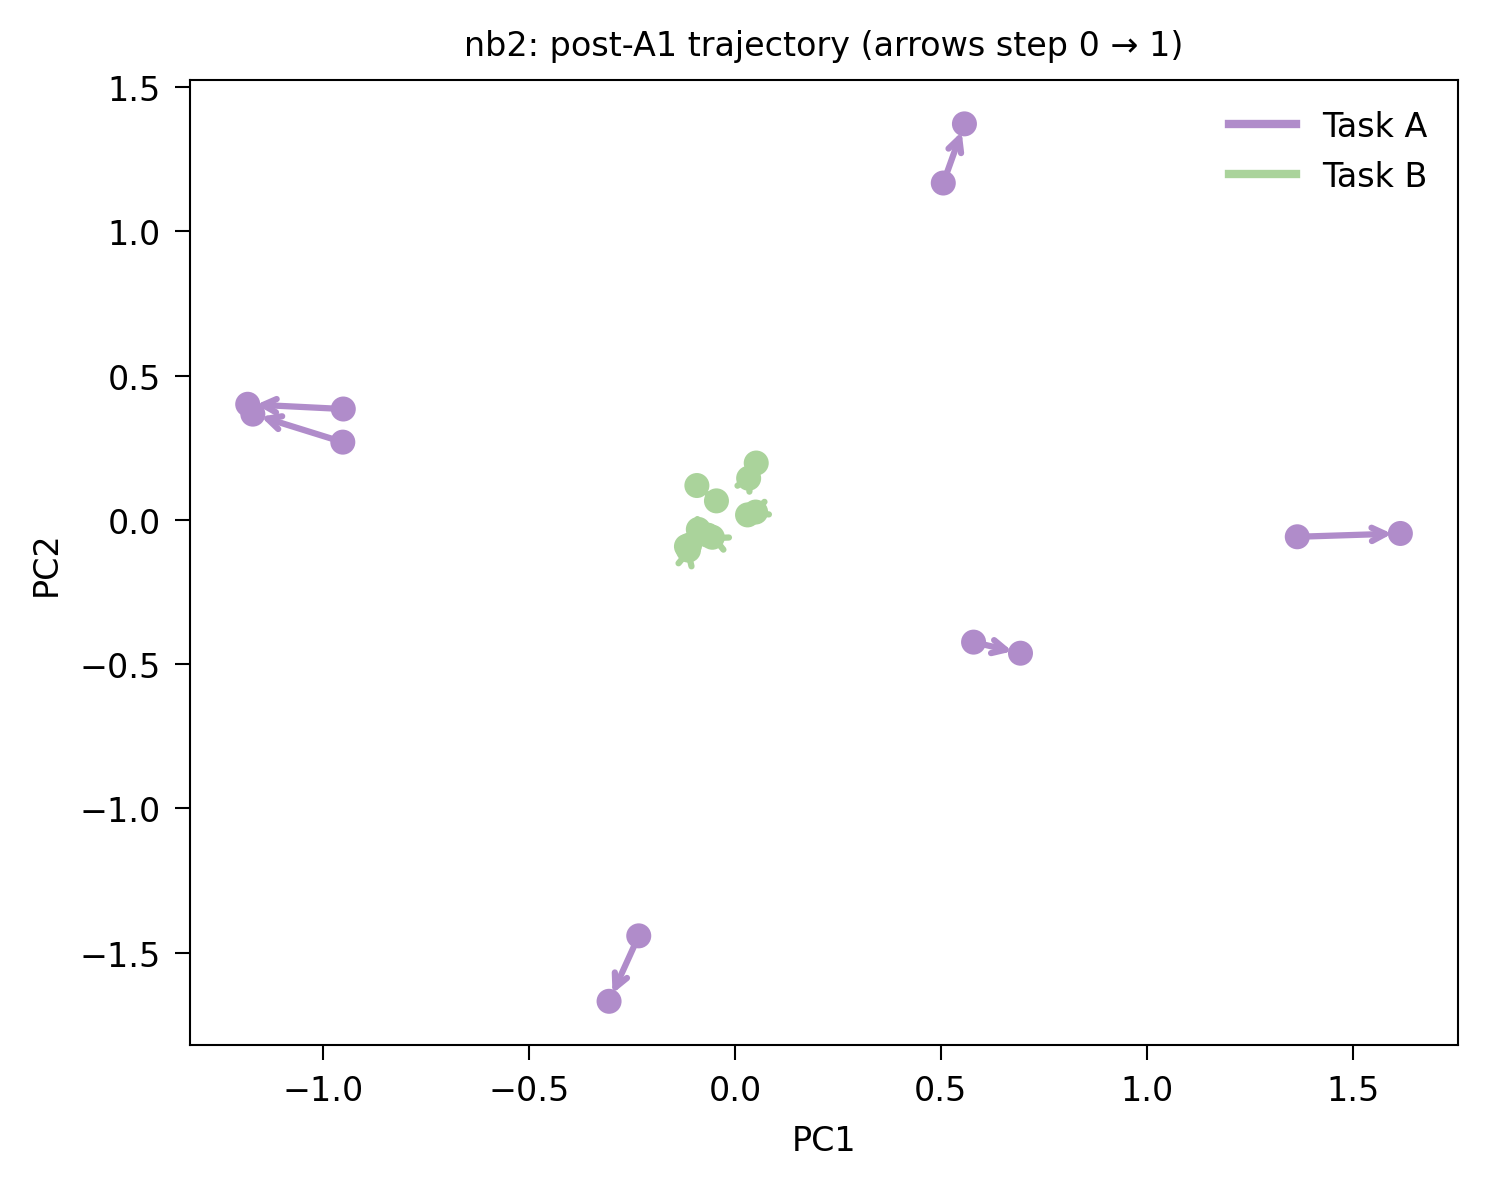

  hiddens_post_phase_1_trajectory shape: (2, 12, 100)


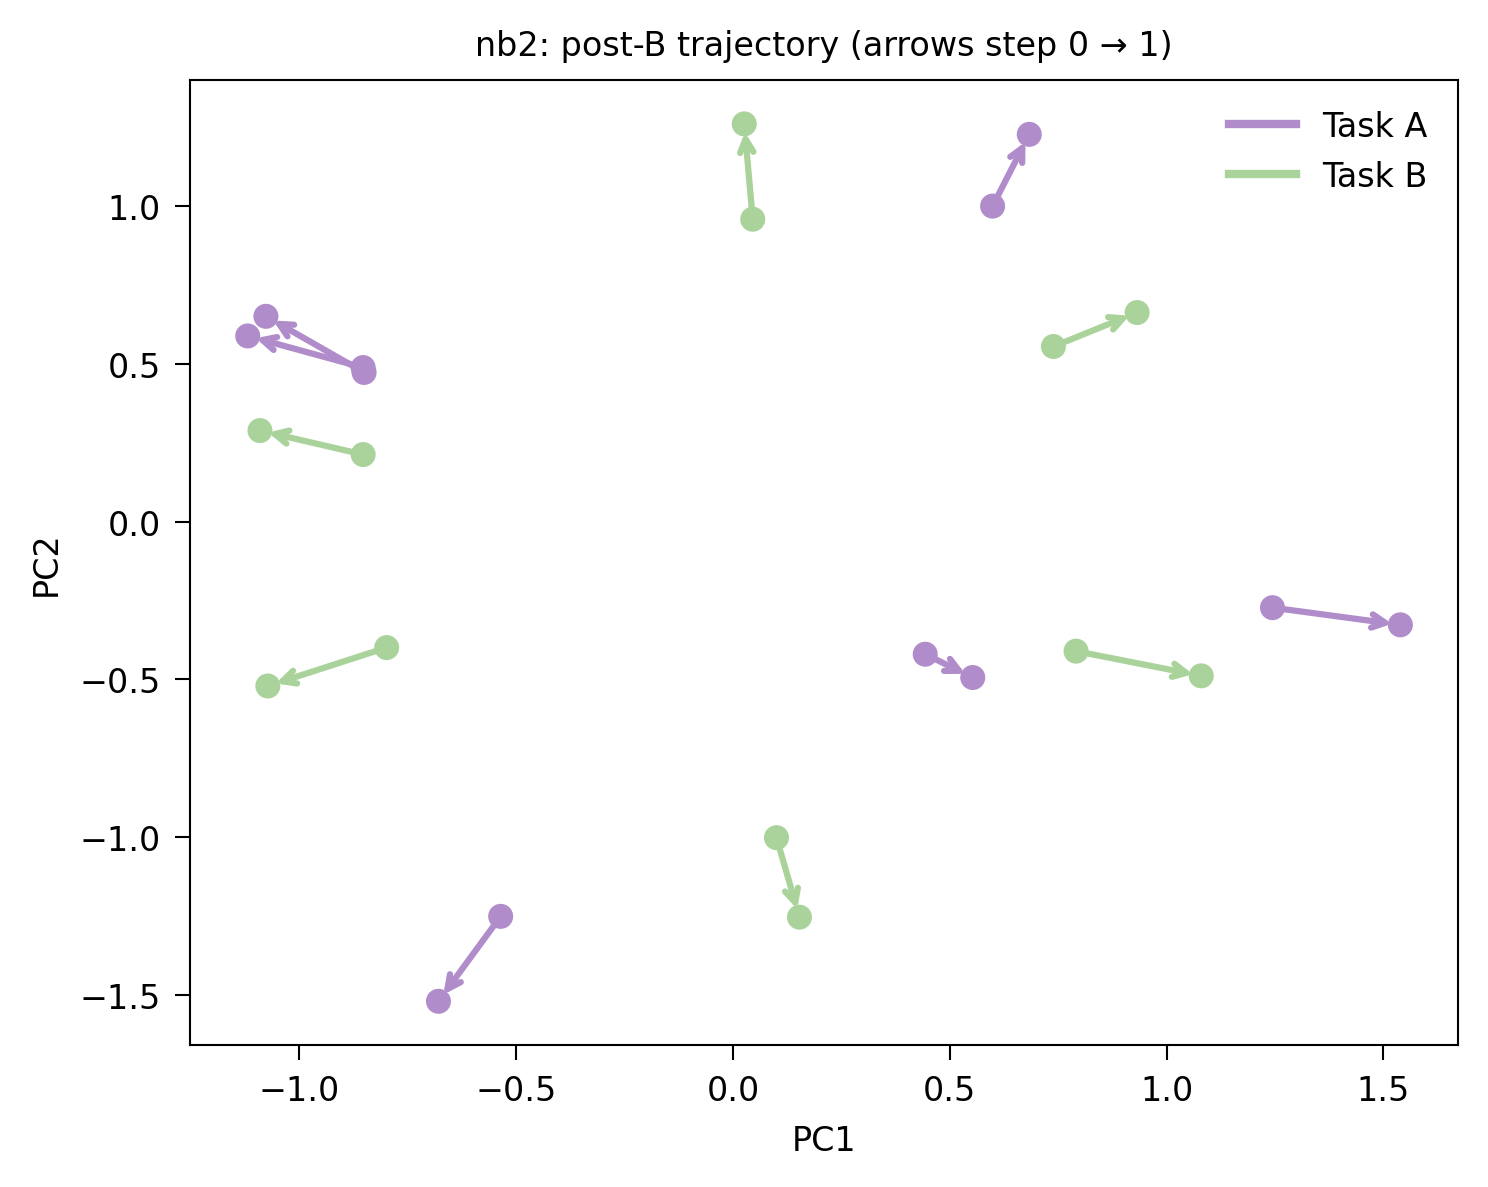

In [16]:
if "nb2" in all_ann_data and len(all_ann_data["nb2"]["same"]) > 0:
    from sklearn.decomposition import PCA
    from a1b2.utils.figure_settings import task_colours

    sample = all_ann_data["nb2"]["same"][0]
    traj_keys = [k for k in sample.keys() if "trajectory" in k or "per_module" in k]
    print("nb2 RNN-extra keys (trajectory/per_module):", traj_keys)
    for phase, phase_label in [(0, "post-A1"), (1, "post-B")]:
        key = f"hiddens_post_phase_{phase}_trajectory"
        if key not in sample:
            print(f"  {key} not found; skip.")
            continue
        traj = sample[key]
        if traj.ndim != 3 or traj.size == 0:
            print(f"  {key} shape {getattr(traj, 'shape', None)}; skip.")
            continue
        T, B, H = traj.shape
        print(f"  {key} shape: {traj.shape}")
        X = traj.reshape(T * B, H)
        if X.shape[0] < 2:
            continue
        pca = PCA(n_components=2).fit(X)
        proj = pca.transform(X)
        proj_3d = proj.reshape(T, B, 2)
        n_stim = B
        fig, ax = plt.subplots(figsize=(5, 4))
        for i in range(n_stim):
            color = task_colours[0] if i < 6 else task_colours[1]
            x0, y0 = proj_3d[0, i, 0], proj_3d[0, i, 1]
            x1, y1 = proj_3d[1, i, 0], proj_3d[1, i, 1]
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
            ax.scatter([x0, x1], [y0, y1], c=[color, color], s=25, zorder=3)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title(f"nb2: {phase_label} trajectory (arrows step 0 → 1)")
        from matplotlib.lines import Line2D
        legend_handles = [Line2D([0], [0], color=task_colours[0], lw=2), Line2D([0], [0], color=task_colours[1], lw=2)]
        ax.legend(handles=legend_handles, labels=["Task A", "Task B"], fontsize=8)
        fig.tight_layout()
        plt.show()
else:
    print("nb2 data not loaded or empty; skip trajectory check.")


## 6. Summary table

Per schedule: mean (SEM) transfer for nb1 and nb2; short interpretation.

In [17]:
if not transfer_all.empty:
    summary = transfer_all.groupby(["run_label", "condition"])["error_diff"].agg(["mean", "sem", "count"]).reset_index()
    summary["mean_sem"] = summary.apply(lambda r: f"{r['mean']:.4f} ({r['sem']:.4f})", axis=1)
    pivot = summary.pivot(index="condition", columns="run_label", values="mean_sem")
    pivot = pivot.reindex(condition_order)
    print("Transfer (error_diff): mean (SEM)")
    try:
        from IPython.display import display
        display(pivot)
    except ImportError:
        print(pivot.to_string())
    print("\nInterpretation: nb2 should show the same qualitative pattern as nb1 (e.g. more interference for far than near than same). "
          "Trajectory data is present only for nb2.")
else:
    print("No transfer data.")

Transfer (error_diff): mean (SEM)


run_label,nb1,nb2
condition,,
same,-0.3196 (0.0237),-0.3510 (0.0176)
near,-0.3948 (0.0563),-0.3726 (0.0173)
far,-0.4370 (0.0263),-0.4179 (0.0124)



Interpretation: nb2 should show the same qualitative pattern as nb1 (e.g. more interference for far than near than same). Trajectory data is present only for nb2.
